# Ayudantía 8 ~ Geo-Pandas (IIC2115) #
Matías Ignacio Guzmán Gómez | matas.guzmn@uc.cl 

10 de Octubre, 2024.

## Introducción

En esta ayudantía, nos adentraremos en el análisis de datos geoespaciales, una herramienta fundamental en diversas disciplinas de la ingeniería. Utilizaremos Python y las bibliotecas `pandas` y `geopandas` para manejar y visualizar datos espaciales. Además, aplicaremos estos conocimientos en el Ejercicio Formativo 1 y 2 del Capítulo 4, que se centra en la Región Metropolitana de Santiago.

Los sistemas de información geográfica (GIS) permiten vincular información georreferenciada con herramientas de software que permiten su manipulación. En esta sesión, aprenderemos a trabajar con datos geoespaciales utilizando archivos **shapefile (.shp)**, visualizarlos y procesarlos de manera eficiente.

## Objetivos

- **Comprender** los conceptos básicos de los Sistemas de Información Geográfica (GIS).
- **Manejar** datos geoespaciales utilizando `pandas` y `geopandas`.
- **Visualizar** información geográfica de manera efectiva.
- **Aplicar** técnicas de análisis espacial en problemas prácticos.
- **Desarrollar** habilidades para manipular y analizar archivos geoespaciales de la Región Metropolitana.
  
## Contenido Teórico

### 1. Sistemas de Información Geográfica (GIS)

Un **GIS** es un sistema que integra hardware, software y datos geográficos para capturar, almacenar, analizar y visualizar información espacial. Estos sistemas son fundamentales en campos como la planificación urbana, el medio ambiente y, en particular, en la ingeniería de transporte.

Un GIS permite gestionar datos en formatos como:

- **Vectores**: Representan entidades geográficas como puntos (estaciones de metro), líneas (rutas de buses) o polígonos (distritos censales).
- **Rásteres**: Son imágenes o mapas representados como una matriz de píxeles.

#### Aplicación en *Ingeniería de Transporte*
En el contexto del transporte, los GIS permiten analizar la accesibilidad a servicios de transporte público, identificar áreas de mejora en la infraestructura y optimizar rutas. Por ejemplo, se pueden usar para evaluar qué barrios carecen de acceso adecuado a estaciones de metro.

### 2. Tipos de Geometrías en GIS

- **Puntos**: Representan ubicaciones específicas en el espacio, como estaciones de metro o paraderos de buses.
- **Líneas**: Conectan dos o más puntos y representan elementos lineales como calles, carreteras o rutas de buses.
- **Polígonos**: Áreas cerradas definidas por líneas, utilizadas para representar regiones, distritos u otras zonas de interés.

Estos tipos de geometrías son fundamentales en el análisis de redes de transporte, ya que permiten modelar la disposición geográfica de infraestructuras y servicios.

### 3. Proyecciones y Sistemas de Coordenadas

Los datos geoespaciales deben estar en un sistema de coordenadas o proyección que permita realizar cálculos espaciales precisos. Una **proyección geográfica** transforma la Tierra tridimensional en una superficie bidimensional (mapa). Las proyecciones más comunes en el análisis de transporte son las que preservan distancias o áreas.

#### Ejemplo en *Ingeniería de Transporte*
Al analizar redes de transporte en una ciudad como Santiago, es crucial que todas las capas de datos (estaciones de metro, rutas de buses, zonas residenciales) estén en el mismo sistema de coordenadas para asegurar que los análisis sean correctos.

### 4. Introducción a `pandas` y `geopandas`

- **`pandas`**: Biblioteca de Python para la manipulación y análisis de datos en estructuras como DataFrames.
- **`geopandas`**: Extiende las funcionalidades de `pandas` para datos geoespaciales, permitiendo la lectura, análisis y visualización de datos geográficos. `geopandas` facilita la manipulación de geometrías y la realización de operaciones espaciales.

### 5. Operaciones Espaciales

Las operaciones espaciales son clave para el análisis de datos geoespaciales:

- **Unión Espacial (Spatial Join)**: Combina datos de dos capas geográficas basándose en su proximidad o intersección.
- **Intersección (Intersection)**: Genera una nueva capa basada en las áreas comunes de dos o más capas.
- **Buffers**: Crea zonas de influencia alrededor de un punto, línea o polígono, útil para medir la proximidad a infraestructuras, como estaciones de metro.

#### Ejemplo en *Ingeniería de Transporte*
Podemos usar estas operaciones para identificar los distritos censales ubicados a menos de 100 metros de una estación de metro o analizar la cobertura de transporte público.

### 6. Visualización de Datos Geoespaciales

La visualización de datos es esencial para interpretar los resultados del análisis geoespacial. Usaremos `geopandas` para generar mapas que representen diferentes variables geográficas. Al graficar polígonos o puntos en un mapa, podemos aplicar escalas de color para reflejar variaciones en los datos, como el costo de construcción en distritos específicos.

## Metodología para datos

1. **Preparación del entorno**: Importación de las bibliotecas necesarias (`pandas`, `geopandas`, `matplotlib`) y configuración del entorno de trabajo en Jupyter Notebook.
2. **Carga y exploración de datos**: Utilización de `geopandas` para leer los archivos .shp y análisis de las estructuras de datos resultantes.
3. **Procesamiento de datos**: Aplicación de técnicas de limpieza y transformación de datos para preparar la información para el análisis.
4. **Visualización y análisis**: Creación de mapas y gráficos que permitan interpretar los datos y extraer conclusiones relevantes.


## Misión 1: Cálculo del costo de construcción de viviendas
### Parte 1: Carga y revisión de los datos geoespaciales

En esta parte de la misión, nos enfocaremos en cargar los archivos geoespaciales correspondientes a los distritos censales de Santiago y revisaremos tanto los datos tabulares como los geoespaciales.

Utilizaremos la biblioteca `geopandas` para leer los archivos `.shp` que contienen la información de los distritos. A continuación, inspeccionaremos los datos para entender su estructura y luego graficaremos un mapa preliminar de los distritos.

#### 1. Carga de los archivos shapefile


In [12]:
# Importamos las bibliotecas necesarias
import geopandas as gpd
import matplotlib.pyplot as plt

# Ruta donde se encuentran los archivos .shp
# Ajustamos las rutas según la estructura de carpetas indicada en las imágenes
distritos_shapefile = "Data/Distritos Censales/Distritos Censales RM.shp"
areas_urbanas_shapefile = "Data/Areas Urbanas/areas_urbanas.shp"

# Cargamos los datos geoespaciales de los distritos censales y las áreas urbanas utilizando GeoPandas
distritos = gpd.read_file(distritos_shapefile)
areas_urbanas = gpd.read_file(areas_urbanas_shapefile)

# Revisamos los primeros registros para comprender la estructura de los datos
print(distritos.head())
print(areas_urbanas.head())

# Mostramos la información del GeoDataFrame para verificar la geometría y columnas disponibles
print(distritos.info())
print(areas_urbanas.info())

                            NOM_REG COD_PROV  NOM_PROV COD_COM   NOM_COM  \
0  Región Metropolitana De Santiago      131  Santiago   13101  Santiago   
1  Región Metropolitana De Santiago      131  Santiago   13101  Santiago   
2  Región Metropolitana De Santiago      131  Santiago   13101  Santiago   
3  Región Metropolitana De Santiago      131  Santiago   13101  Santiago   
4  Región Metropolitana De Santiago      131  Santiago   13101  Santiago   

      NOM_DIS     CODIGO     E      D      C3      C2   ABC1  ADIMARK_T  \
0      Huelén  1310101.0  28.0  397.0  1232.0  1390.0  365.0     3412.0   
1      Moneda  1310102.0  51.0  560.0   999.0   903.0  228.0     2741.0   
2  Amunátegui  1310103.0  38.0  389.0   956.0   891.0  113.0     2387.0   
3      Brasil  1310104.0  52.0  657.0  1728.0  2202.0  423.0     5062.0   
4   Chacabuco  1310105.0  45.0  643.0  1092.0   974.0  145.0     2899.0   

         Area  Densidad  1_UF_M2  \
0   704315.75     48.44    31.09   
1  1166659.89     23

### Explicación del código:
- **geopandas.read_file()**: Esta función carga los datos geoespaciales desde los archivos shapefile (.shp). Los datos incluyen tanto información tabular como la geometría.
- **distritos.head() y areas_urbanas.head()**: Nos muestran los primeros registros de ambos DataFrames, lo que nos permite entender las columnas disponibles y el tipo de datos.
- **distritos.info() y areas_urbanas.info()**: Proporcionan un resumen de las columnas, el tipo de datos de cada una, y si existen valores nulos. Esto es útil para planificar las operaciones que haremos posteriormente con estos datos.


#### 2. Visualización preliminar de los distritos censales y las áreas urbanas

A continuación, realizaremos una visualización inicial para obtener una mejor idea de cómo se distribuyen los distritos censales y las áreas urbanas en el área de estudio.

##### Atributos de los Distritos Censales:

- **NOM_REG**: Nombre de la región
- **COD_PROV**: Código de la provincia
- **NOM_PROV**: Nombre de la provincia
- **COD_COM**: Código de la comuna
- **NOM_COM**: Nombre de la comuna
- **NOM_DIS**: Nombre del distrito censal
- **CODIGO**: Código del distrito censal
- **E**: Número de hogares clase E por distrito censal
- **D**: Número de hogares clase D por distrito censal
- **C3**: Número de hogares clase C3 por distrito censal
- **C2**: Número de hogares clase C2 por distrito censal
- **ABC1**: Número de hogares clase ABC1 por distrito censal
- **ADIMARK_T**: Total de hogares
- **Area**: Área del distrito censal
- **Densidad**: Densidad poblacional del distrito censal
- **1_UF_M2**: Valor del metro cuadrado en UF

##### Visualización de áreas por distrito:

Vamos a visualizar las áreas de los distritos, y estos se colorearán en función de alguna de las variables, como por ejemplo el valor del metro cuadrado o la densidad poblacional.


In [13]:
distritos.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.840, 345650.511 6..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.320 6298892.632, 345672.277 6..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."


In [14]:
distritos['NOM_PROV'].value_counts()

NOM_PROV
Santiago      312
Melipilla      41
Maipo          34
Cordillera     26
Talagante      20
Chacabuco      16
Name: count, dtype: int64

El código `distritos['NOM_PROV'].value_counts()` permite contar cuántos distritos censales pertenecen a cada provincia. Esto es útil para obtener una visión rápida de cómo se distribuyen los distritos en las distintas provincias de la Región Metropolitana. La función `value_counts()` devuelve una serie donde se enlistan las provincias junto con la cantidad de distritos que pertenecen a cada una.


In [15]:
distritos.describe()

,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2
count,4.490000e+02,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,4.490000e+02,449.000000,449.000000
mean,1.320575e+06,198.677060,1221.055679,1239.336303,799.746102,215.561247,3674.376392,3.427451e+07,21.551871,5.048530
std,1.553424e+04,230.595397,1209.411846,1090.013162,870.943145,519.746952,2840.039537,1.390632e+08,17.448771,5.664918
min,1.310101e+06,0.000000,20.000000,11.000000,2.000000,0.000000,48.000000,3.673118e+05,0.000000,0.000000
25%,1.311018e+06,45.000000,373.000000,496.000000,216.000000,10.000000,1801.000000,1.028728e+06,1.810000,0.790000
50%,1.312204e+06,123.000000,924.000000,1110.000000,547.000000,43.000000,3548.000000,1.682413e+06,23.030000,4.220000
75%,1.320305e+06,277.000000,1843.000000,1632.000000,1046.000000,147.000000,4756.000000,1.732345e+07,35.090000,6.230000
max,1.360503e+06,2036.000000,14371.000000,8811.000000,5481.000000,5135.000000,26477.000000,2.022821e+09,73.240000,41.130000


In [16]:
areas_urbanas.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
0,Chiguayante,Ciudad,29855.998337,1.038076e+07,"POLYGON ((140044.634 5911024.284, 140051.361 5..."
1,Lota,Ciudad,14233.349738,5.262642e+06,"POLYGON ((131359.666 5889462.902, 131475.343 5..."
2,Coronel,Ciudad,41577.791832,1.551685e+07,"POLYGON ((127278.440 5896965.436, 127411.675 5..."
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.830 5870293.970, 168725.579 5..."
4,Concepción,Ciudad,82986.894378,3.454227e+07,"POLYGON ((133504.854 5919782.212, 136052.580 5..."


In [17]:
areas_urbanas["TIPO_AREA"].value_counts()

TIPO_AREA
Pueblo       189
Ciudad       178
Aldea         30
Localidad      2
Caserio        1
Name: count, dtype: int64

El código `areas_urbanas["TIPO_AREA"].value_counts()` permite contar cuántas áreas urbanas pertenecen a cada tipo de área. La columna `TIPO_AREA` contiene la clasificación de las áreas urbanas y la función `value_counts()` devuelve una serie que muestra la cantidad de ocurrencias de cada tipo. Esto nos proporciona una visión general sobre la clasificación y distribución de las áreas urbanas en el conjunto de datos.


### Parte 3: Visualización preliminar de los distritos censales y áreas urbanas de Santiago

En esta sección, vamos a visualizar los distritos censales dentro del área urbana de Santiago. El objetivo es tener una primera vista gráfica tanto de los distritos censales como de las áreas urbanas de Santiago, lo que nos permitirá obtener una mejor comprensión de su distribución geográfica.

Para ello, utilizaremos la función `plot()` de `GeoPandas` para graficar los distritos y las áreas urbanas. Primero, realizaremos una visualización de todos los distritos censales de la Región Metropolitana. Luego, filtraremos los datos geoespaciales para mostrar únicamente la comuna de Santiago dentro de las áreas urbanas, con el fin de centrarnos en esa área específica.

Las visualizaciones iniciales serán útiles para asegurarnos de que los datos estén bien cargados y para verificar la correcta delimitación de las áreas urbanas de Santiago.


<Axes: >

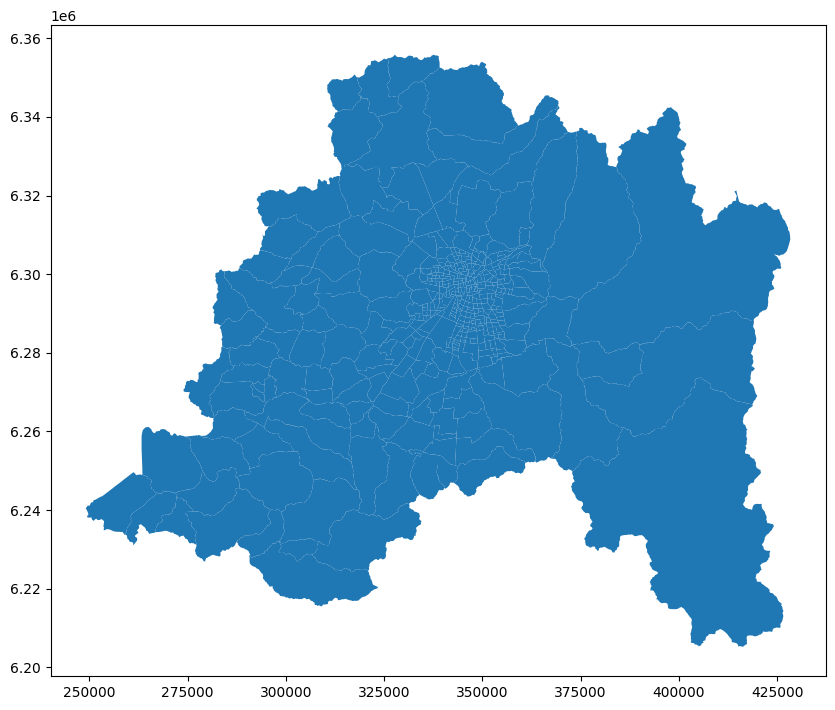

In [21]:
distritos.plot(figsize = (10,10))

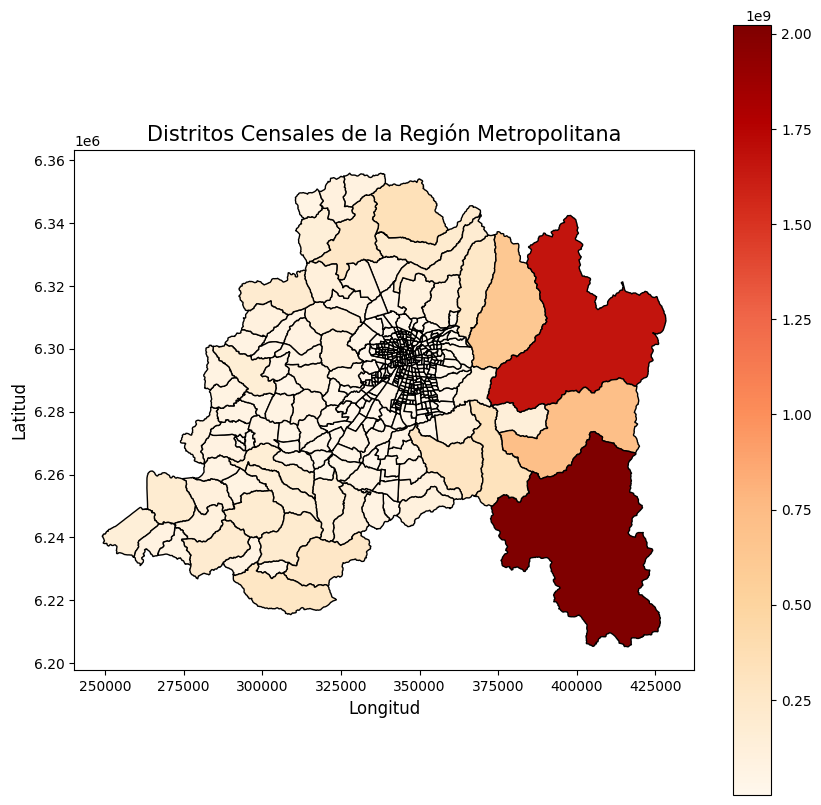

In [19]:
# Utilizamos una escala de colores basada en el área de cada distrito
fig, ax = plt.subplots(figsize=(10, 10))

# Graficamos los distritos con un esquema de colores que refleja el área de cada uno
distritos.plot(column='Area', ax=ax, legend=True, cmap='OrRd', edgecolor='black')

# Añadimos título y etiquetas de ejes
plt.title('Distritos Censales de la Región Metropolitana', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, hemos mejorado la visualización de los distritos censales al utilizar una escala de colores basada en el área de cada distrito. Esto nos permite obtener una representación más intuitiva de las dimensiones de los distritos dentro de la Región Metropolitana.

Además, hemos agregado una leyenda que facilita la interpretación de los valores de área, y hemos incluido un título y etiquetas en los ejes para proporcionar contexto adicional al gráfico.

Al utilizar un esquema de colores (en este caso, un gradiente de tonos rojos), podemos distinguir fácilmente las diferencias en el tamaño de los distritos, haciendo que el gráfico sea más informativo y visualmente atractivo.


<Axes: >

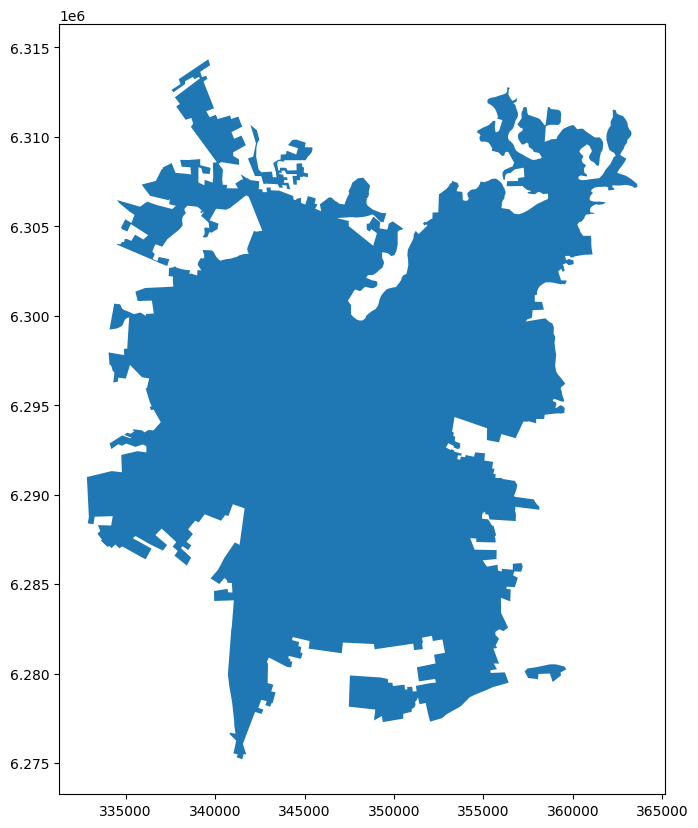

In [22]:
santiago_urbano = areas_urbanas.loc[areas_urbanas['NOMBRE']=='Santiago']
santiago_urbano.plot(figsize = (10,10))

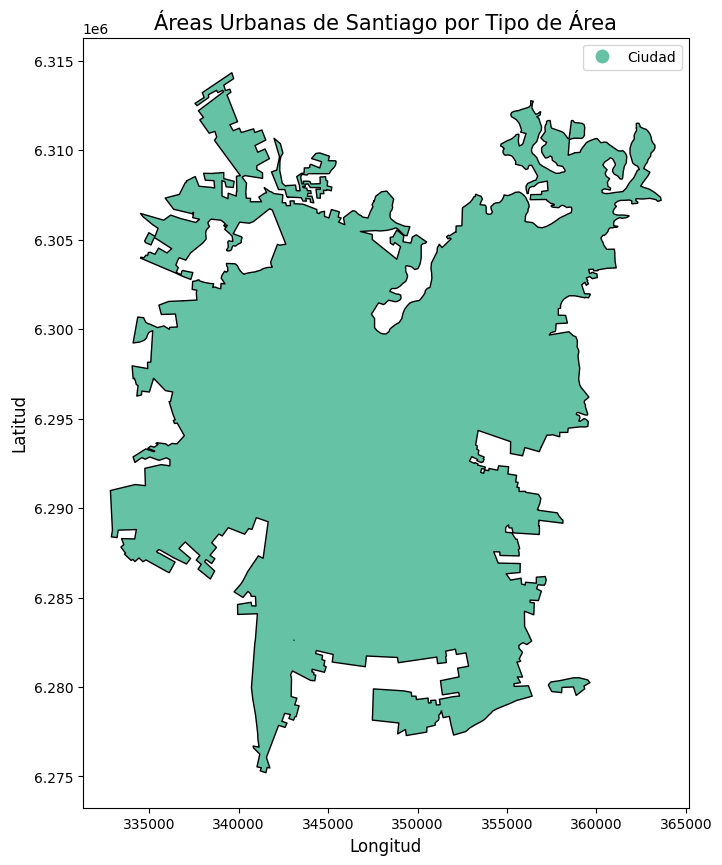

In [23]:
# Filtramos solo el área urbana de Santiago
santiago_urbano = areas_urbanas.loc[areas_urbanas['NOMBRE']=='Santiago']

# Graficamos el área urbana de Santiago, aplicando color basado en el tipo de área
fig, ax = plt.subplots(figsize=(10, 10))

# Usamos 'TIPO_AREA' para colorear las áreas de Santiago según su tipo
santiago_urbano.plot(column='TIPO_AREA', ax=ax, cmap='Set2', legend=True, edgecolor='black')

# Añadimos título y etiquetas de ejes
plt.title('Áreas Urbanas de Santiago por Tipo de Área', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, visualizamos las áreas urbanas de Santiago diferenciando los tipos de área mediante una escala de colores. El uso de la columna `TIPO_AREA` nos permite asignar un color distinto a cada categoría, lo que mejora la comprensión de cómo se distribuyen las áreas según su clasificación.

Hemos añadido una leyenda para que los colores sean interpretables, así como un título y etiquetas para los ejes, haciendo el gráfico más fácil de entender. Esta visualización resulta más atractiva y útil, ya que permite observar las diferencias entre los tipos de áreas urbanas dentro de Santiago.


### Parte 4: Intersección de distritos censales con el área urbana de Santiago

En esta etapa de la misión, nos centraremos en realizar la intersección espacial entre los distritos censales y el área urbana de Santiago. El objetivo es extraer únicamente los distritos que se encuentran dentro del área urbana de Santiago, eliminando así aquellos que no pertenecen a esta zona.

Para ello, utilizaremos la función `overlay()` de `GeoPandas`, que nos permitirá combinar las geometrías de los distritos censales con las de las áreas urbanas y filtrar los distritos que están completamente dentro de la comuna de Santiago. Esta operación espacial es crucial para limitar nuestro análisis a las áreas de interés, lo que facilitará los cálculos posteriores, como el costo de construcción de viviendas.

A continuación, se presentará el proceso para realizar esta intersección y preparar los datos para los análisis subsiguientes.


In [24]:

distritos.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
santiago_urbano.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

La línea `distritos.crs` permite consultar el sistema de referencia de coordenadas (CRS, por sus siglas en inglés) asociado al GeoDataFrame `distritos`. El CRS es fundamental para realizar operaciones geoespaciales, ya que define cómo se proyectan los datos en el mapa. Es necesario que todos los conjuntos de datos geoespaciales involucrados en una operación (como la intersección) tengan el mismo CRS para garantizar que las geometrías se alineen correctamente.

Al consultar el CRS, podemos verificar si los datos están en el mismo sistema de coordenadas que otros conjuntos de datos que planeamos utilizar.


<Axes: >

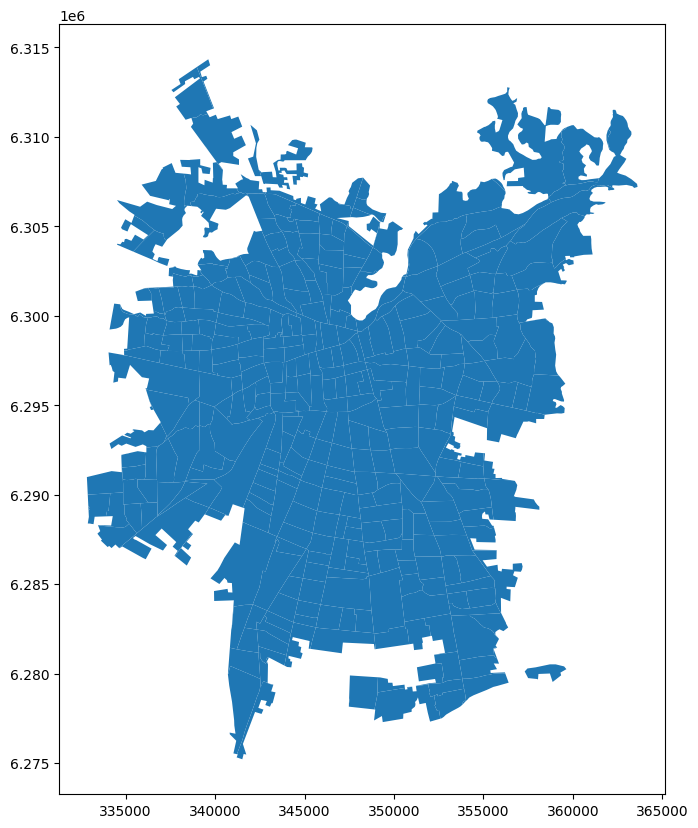

In [26]:
distritos_urbanos = gpd.overlay(santiago_urbano, distritos, how='intersection')
distritos_urbanos.plot(figsize=(10,10))

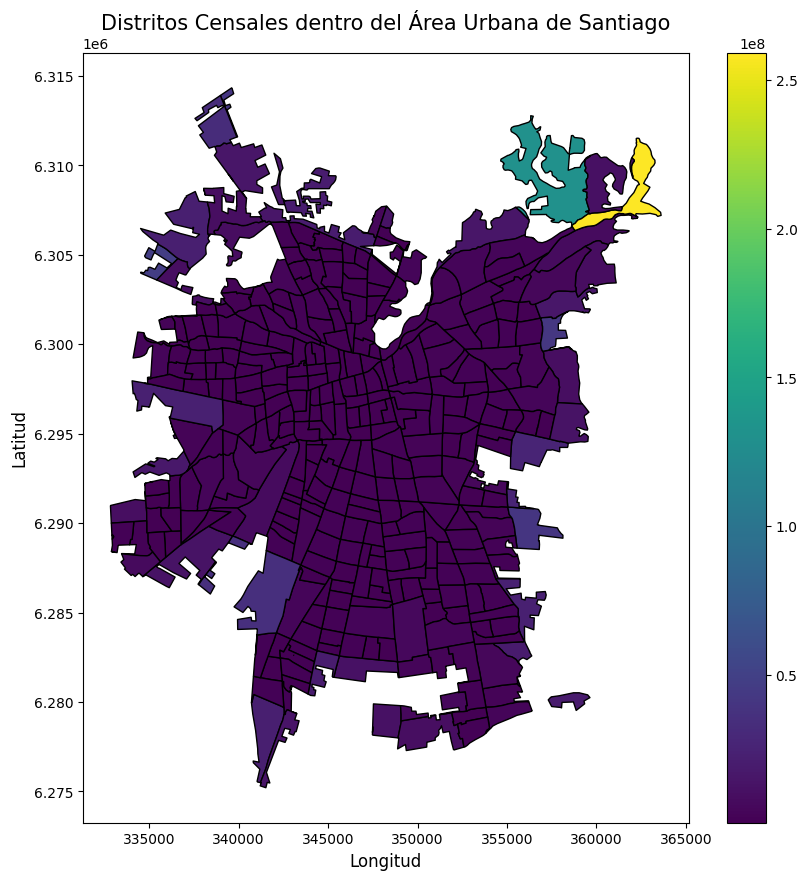

In [27]:
# Realizamos la intersección espacial entre el área urbana de Santiago y los distritos censales
distritos_urbanos = gpd.overlay(santiago_urbano, distritos, how='intersection')

# Graficamos los distritos urbanos resultantes de la intersección, coloreados según el área de cada distrito
fig, ax = plt.subplots(figsize=(10, 10))

# Usamos el área del distrito como la columna para colorear
distritos_urbanos.plot(column='Area', ax=ax, cmap='viridis', edgecolor='black', legend=True)

# Añadimos título y etiquetas
plt.title('Distritos Censales dentro del Área Urbana de Santiago', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, hemos mejorado la visualización de los distritos urbanos resultantes de la intersección entre el área urbana de Santiago y los distritos censales. Hemos utilizado una escala de colores basada en el área de cada distrito, lo que permite visualizar de forma intuitiva las diferencias en el tamaño de los distritos.

El uso de la función `overlay()` nos permite aislar los distritos que se encuentran dentro de Santiago urbano, lo que es crucial para concentrar el análisis únicamente en la zona de interés. La escala de colores, proporcionada por el esquema `viridis`, mejora la interpretación visual del gráfico al mostrar cómo varían las áreas de los distritos. Además, hemos añadido una leyenda para que los colores sean fáciles de interpretar, así como un título y etiquetas en los ejes para contextualizar mejor el gráfico. 

Este enfoque hace que el gráfico sea más informativo y visualmente atractivo, permitiendo que el análisis de los distritos censales sea más claro y accesible.


### Parte 5: Cálculo del costo de construcción por distrito

En esta etapa de la misión, nos enfocaremos en calcular el costo estimado para construir viviendas de un piso en cada distrito urbano de Santiago. Utilizando los datos disponibles, calcularemos el costo por distrito basado en el valor del metro cuadrado (en UF) y la superficie total de cada distrito.

Para realizar este cálculo, utilizaremos el valor actual de la **Unidad de Fomento (UF)**, que al día de hoy (domingo 6/10/24) es de **37.933,14 pesos**. Este valor nos permitirá convertir los costos de UF/m² a pesos chilenos, obteniendo así el costo monetario total para edificar en cada distrito.

Este cálculo es fundamental para entender el costo total de construcción en diferentes áreas de la ciudad, y nos permitirá visualizar las diferencias económicas entre los distritos. Para ello, agregaremos una nueva columna al GeoDataFrame de los distritos urbanos, en la que almacenaremos el costo de construcción calculado en función del área y el valor del metro cuadrado.

Este análisis facilitará la identificación de los distritos donde el costo de construcción es mayor, proporcionando información clave para la toma de decisiones urbanísticas y económicas.



In [28]:
distritos_urbanos['Precio']=37933.14*distritos_urbanos['1_UF_M2']*distritos_urbanos['Area']
distritos_urbanos.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,Precio
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6...",8.306287e+11
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.610 6299612.269, 346298.704 6...",9.337820e+11
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.570, 345809.442 6...",2.317324e+11
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6...",2.961751e+11
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6...",3.448062e+11


<Axes: >

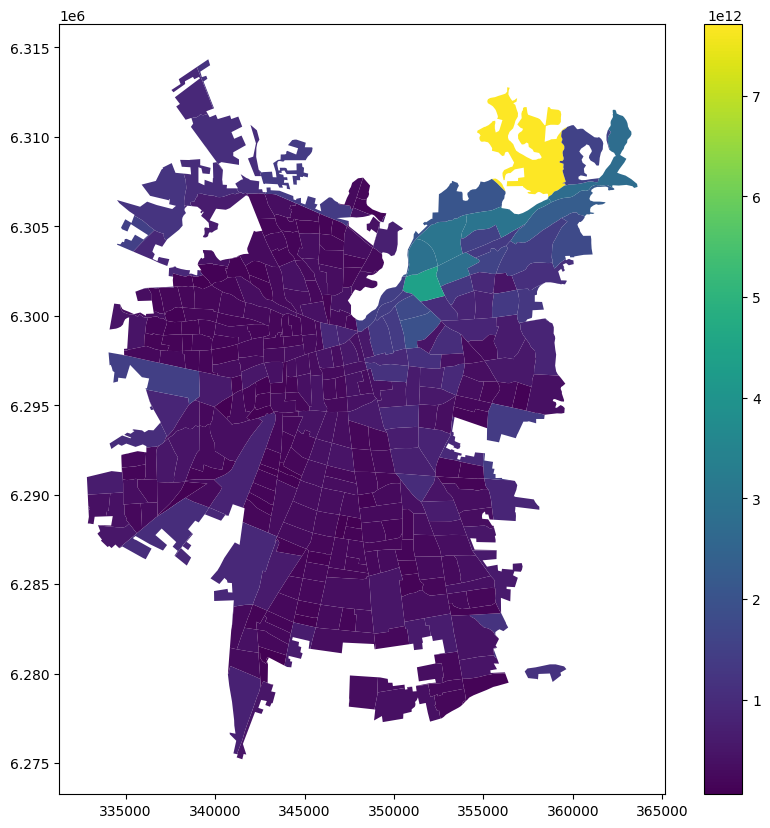

In [30]:
distritos_urbanos.plot(figsize=(10,10),column='Precio', legend=True)

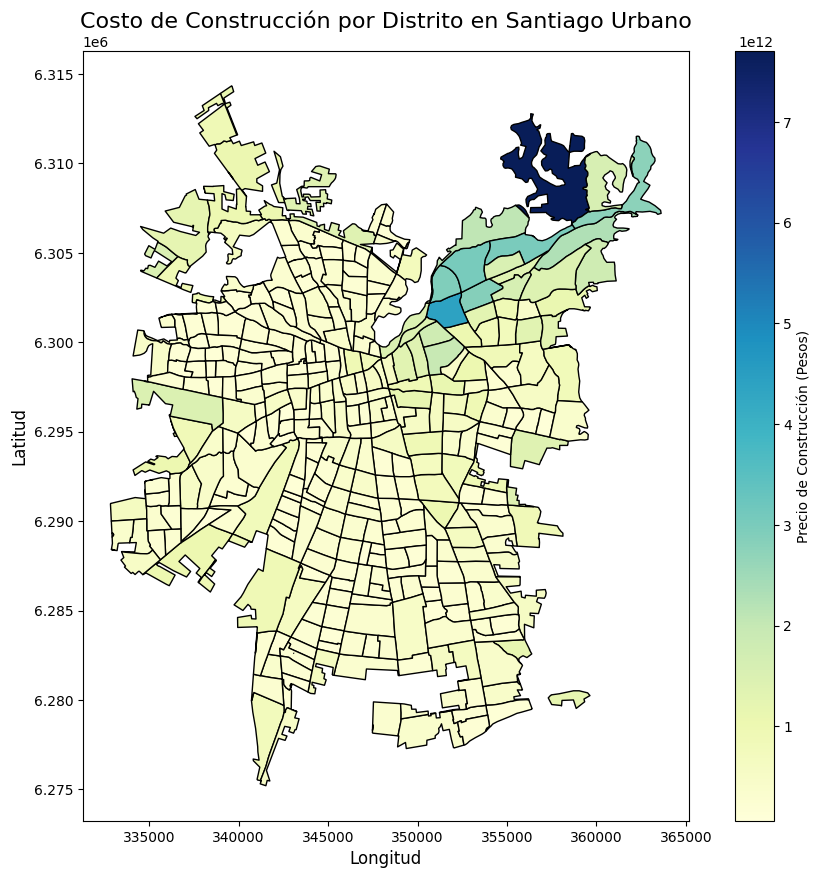

In [29]:
import matplotlib.pyplot as plt

# Ajustamos la figura y el color del gráfico
fig, ax = plt.subplots(figsize=(12, 10))

# Graficamos los distritos urbanos coloreados según la columna 'Precio', con un esquema de colores y leyenda
distritos_urbanos.plot(
    column='Precio', 
    ax=ax, 
    cmap='YlGnBu',  # Usamos un esquema de colores atractivo
    legend=True, 
    edgecolor='black',  # Agregamos bordes negros a los distritos
    legend_kwds={'label': "Precio de Construcción (Pesos)", 'orientation': "vertical"}  # Añadimos una leyenda con etiquetas claras
)

# Añadimos un título y etiquetas a los ejes
plt.title('Costo de Construcción por Distrito en Santiago Urbano', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, hemos visualizado los distritos urbanos de Santiago utilizando una escala de colores basada en el costo de construcción (`Precio`) por cada distrito. Utilizamos la paleta de colores `YlGnBu`, que proporciona una transición suave entre tonos claros y oscuros, facilitando la interpretación visual de los valores.

Además, hemos añadido bordes negros a los distritos para una mayor claridad en la delimitación de cada uno, y hemos incorporado una leyenda con una etiqueta descriptiva, lo que ayuda a interpretar los valores asociados a los colores.

El título y las etiquetas en los ejes hacen que el gráfico sea más comprensible y le dan un contexto adecuado, mejorando tanto su atractivo visual como su utilidad para la toma de decisiones. Con estas mejoras, el gráfico no solo es más estético, sino también más informativo y fácil de interpretar.


## Misión 2: Ranking de distritos más poblados cercanos a estaciones de metro

En esta misión, nos enfocaremos en identificar los cinco distritos censales más poblados que se encuentran a menos de 100 metros de una estación de metro. Para lograrlo, realizaremos un análisis espacial utilizando un **buffer** alrededor de las estaciones de metro, lo que nos permitirá seleccionar aquellos distritos que se solapen con esta área de influencia.

Primero, crearemos un buffer de 100 metros alrededor de cada estación de metro. Luego, realizaremos una operación de unión espacial (`spatial join`) entre los distritos censales y el buffer, con el objetivo de encontrar los distritos que se intersectan con las áreas de influencia de las estaciones. Finalmente, ordenaremos los distritos por población y generaremos un ranking de los cinco más poblados.

Este análisis nos permitirá identificar cuáles son los distritos más densamente poblados con acceso cercano al transporte público, lo que puede ser clave para la planificación urbana y el desarrollo de infraestructura.


<Axes: >

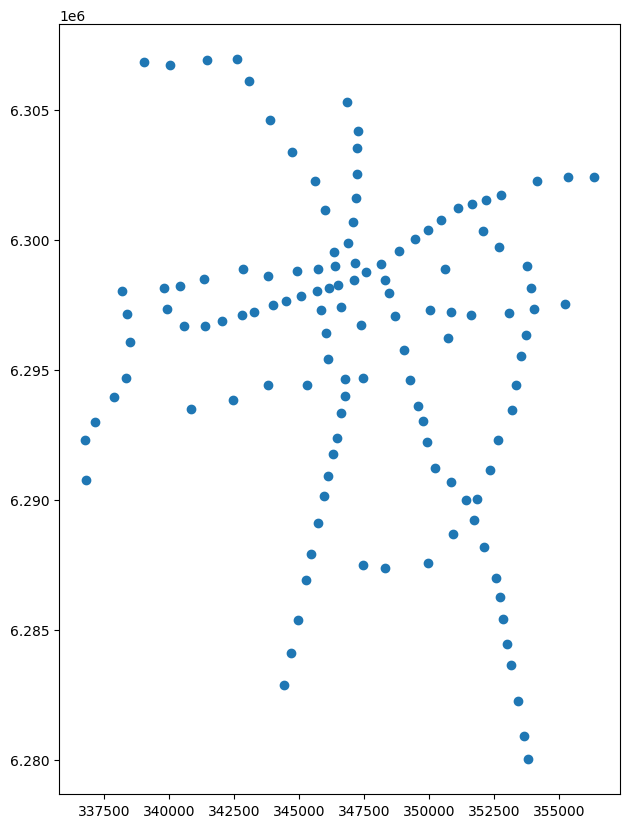

In [31]:
estaciones_metro = gpd.read_file('Data/Metro 2020/Estaciones_2020/Estaciones_2020.shp')
estaciones_metro.head()
estaciones_metro.plot(figsize=(10,10))

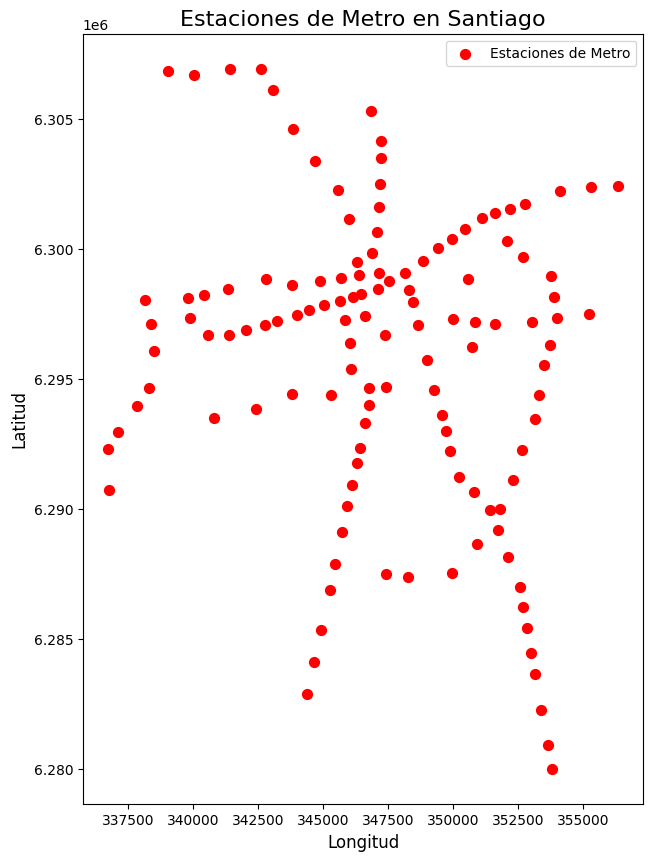

In [32]:
# Graficamos las estaciones de metro con mejoras visuales
fig, ax = plt.subplots(figsize=(10, 10))

# Usamos un color y estilo distintivo para las estaciones de metro
estaciones_metro.plot(ax=ax, color='red', marker='o', markersize=50, label='Estaciones de Metro')

# Añadimos título y etiquetas a los ejes
plt.title('Estaciones de Metro en Santiago', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Añadimos una leyenda para identificar las estaciones de metro
plt.legend()

# Mostramos el gráfico
plt.show()

En este gráfico, hemos representado las estaciones de metro de Santiago utilizando puntos de color rojo y un tamaño de marcador significativo para hacerlas más visibles en el mapa. Esta visualización permite identificar claramente la ubicación de las estaciones dentro del área de estudio.

El gráfico incluye un título descriptivo y etiquetas en los ejes, lo que proporciona un contexto claro y facilita la comprensión de la distribución geográfica de las estaciones. También hemos añadido una leyenda para que sea fácil identificar los puntos como estaciones de metro.

Estas mejoras hacen que el gráfico sea más atractivo visualmente y más informativo, facilitando la interpretación de los datos.


In [33]:
estaciones_metro.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Proyección sigue siendo la misma.

C:\Users\matii\AppData\Local\Temp\ipykernel_12484\795736641.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


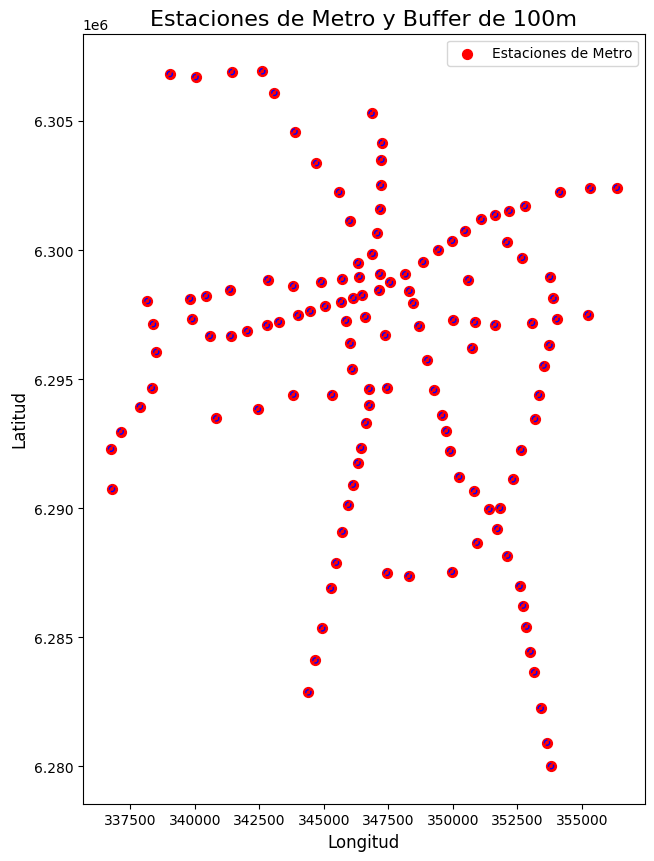

In [34]:
# Generamos el buffer de 100 metros alrededor de las estaciones de metro
buffer_estaciones_metro = estaciones_metro.copy()
buffer_estaciones_metro['geometry'] = buffer_estaciones_metro.buffer(100)

# Graficamos tanto las estaciones como los buffers de manera más visual
fig, ax = plt.subplots(figsize=(10, 10))

# Graficamos las estaciones de metro como puntos rojos
estaciones_metro.plot(ax=ax, color='red', marker='o', markersize=50, label='Estaciones de Metro')

# Graficamos los buffers de 100 metros alrededor de las estaciones en color transparente con borde azul
buffer_estaciones_metro.plot(ax=ax, color='none', edgecolor='blue', label='Buffer 100m', linestyle='--')

# Añadimos título y etiquetas a los ejes
plt.title('Estaciones de Metro y Buffer de 100m', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Añadimos una leyenda para identificar las estaciones de metro y los buffers
plt.legend()

# Mostramos el gráfico
plt.show()


In [35]:
buffer_estaciones_metro.head()

,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,"POLYGON ((345817.366 6289105.444, 345816.885 6..."
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,"POLYGON ((344999.120 6298781.571, 344998.638 6..."
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,"POLYGON ((343908.803 6298622.125, 343908.321 6..."
3,5,7,L4A,SAN RAMON,San Ramón,346685.4133,6.287624e+06,"POLYGON ((347536.975 6287501.270, 347536.494 6..."
4,6,7,L4A,SANTA ROSA,Santa Rosa,348282.5816,6.287378e+06,"POLYGON ((348382.582 6287378.409, 348382.100 6..."


En este gráfico, hemos visualizado las estaciones de metro junto con un buffer de 100 metros alrededor de cada una de ellas. Los puntos rojos representan las estaciones de metro, mientras que los círculos azules con borde punteado muestran el área de influencia de 100 metros alrededor de cada estación.

El uso de un borde azul punteado para los buffers facilita su distinción de las estaciones mismas, sin oscurecer la visualización de los puntos. Además, el gráfico incluye un título y etiquetas en los ejes para proporcionar contexto, y una leyenda que ayuda a interpretar los elementos representados.

Este enfoque mejora significativamente la visualización del buffer y las estaciones, haciendo que el gráfico sea más atractivo y fácil de interpretar.


In [36]:
distritos_metro = gpd.sjoin(distritos, buffer_estaciones_metro, predicate='intersects')
distritos_metro.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,1_UF_M2,geometry,index_right,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06
9,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,1310110.0,28.0,394.0,1225.0,...,18.44,"POLYGON ((347488.430 6298672.836, 347569.109 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",60,63,1,L1,SANTA LUCIA,Santa Lucía,347075.4514,6.298439e+06
10,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Isidro,1310111.0,53.0,779.0,1892.0,...,14.81,"POLYGON ((346958.269 6298373.448, 347071.088 6...",60,63,1,L1,SANTA LUCIA,Santa Lucía,347075.4514,6.298439e+06
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",80,84,5,L5,BELLAS ARTES,Bellas Artes,347155.8810,6.299103e+06


En esta línea de código, utilizamos la función `gpd.sjoin()` para realizar una unión espacial (*spatial join*) entre los distritos censales y los buffers de 100 metros alrededor de las estaciones de metro.

- **`gpd.sjoin()`**: Realiza una unión espacial entre dos GeoDataFrames. En este caso, estamos uniendo los distritos censales (`distritos`) con los buffers de las estaciones de metro (`buffer_estaciones_metro`).
- **`predicate='intersects'`**: Este parámetro especifica que queremos seleccionar los distritos que "intersectan" (o se solapan) con los buffers de las estaciones de metro. Es decir, se seleccionan los distritos que están dentro o tocan el área de influencia de 100 metros de una estación de metro.
- **`distritos_metro.head()`**: Muestra las primeras filas del nuevo GeoDataFrame `distritos_metro`, que contiene los distritos censales que se encuentran dentro de los 100 metros de una estación de metro.

Con este código, podemos identificar cuáles distritos están cercanos a una estación de metro y usarlos para los análisis posteriores, como el ranking de los distritos más poblados con acceso cercano al transporte público.


In [37]:
distritos_metro['CODIGO'].value_counts().head()

CODIGO
1310113.0    5
1312308.0    4
1311001.0    4
1310102.0    4
1313001.0    4
Name: count, dtype: int64

El código `distritos_metro['CODIGO'].value_counts().head()` nos permite contar cuántas veces aparece cada código de distrito en el GeoDataFrame `distritos_metro`, que contiene los distritos que intersectan con los buffers de las estaciones de metro.

- **`distritos_metro['CODIGO']`**: Accedemos a la columna `CODIGO`, que identifica a cada distrito censal por un código único.
- **`value_counts()`**: Esta función cuenta cuántas veces aparece cada valor único en la columna, en este caso, el código del distrito. Esto es útil para ver si hay distritos que intersectan con múltiples buffers o si un mismo distrito se repite por alguna razón en el conjunto de datos.
- **`head()`**: Muestra solo los primeros 5 distritos con mayor número de apariciones en los datos.

Este código es útil para revisar si hay distritos que se intersectan con más de un buffer, o si hay distritos con una presencia dominante en el área de influencia de las estaciones de metro.

In [38]:
distritos_metro = distritos_metro.drop_duplicates(subset=['CODIGO'])
distritos_metro['CODIGO'].value_counts().head()

CODIGO
1310101.0    1
1312405.0    1
1311703.0    1
1311707.0    1
1312605.0    1
Name: count, dtype: int64

Eliminados.

In [39]:
distritos_metro['Poblacion'] = distritos_metro['Area']*distritos_metro['Densidad']
distritos_metro.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,geometry,index_right,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,Poblacion
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,"POLYGON ((346775.511 6299463.724, 346788.392 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06,3.411705e+07
9,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,1310110.0,28.0,394.0,1225.0,...,"POLYGON ((347488.430 6298672.836, 347569.109 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06,3.764800e+07
10,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Isidro,1310111.0,53.0,779.0,1892.0,...,"POLYGON ((346958.269 6298373.448, 347071.088 6...",60,63,1,L1,SANTA LUCIA,Santa Lucía,347075.4514,6.298439e+06,5.310903e+07
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,...,"POLYGON ((345880.280 6299633.958, 345961.610 6...",55,58,1,L1,LA MONEDA,La Moneda,346187.8506,6.298170e+06,2.740484e+07
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,...,"POLYGON ((345546.017 6299748.840, 345650.511 6...",55,58,1,L1,LA MONEDA,La Moneda,346187.8506,6.298170e+06,2.387080e+07


En esta línea de código, calculamos la población estimada de cada distrito censal dentro del área de influencia de las estaciones de metro.

- **`distritos_metro['Poblacion']`**: Creamos una nueva columna llamada `Poblacion` en el GeoDataFrame `distritos_metro` que almacenará la población estimada de cada distrito.
- **`distritos_metro['Area']*distritos_metro['Densidad']`**: El cálculo de la población se realiza multiplicando el área de cada distrito (`Area`) por su densidad poblacional (`Densidad`). Este cálculo nos proporciona una estimación del número de personas que viven en cada distrito censal dentro de los 100 metros de una estación de metro.
- **`distritos_metro.head()`**: Muestra las primeras filas del DataFrame, permitiéndonos verificar que la nueva columna `Poblacion` se ha añadido correctamente y que los cálculos son coherentes.

Este paso es crucial para el análisis posterior, ya que nos permitirá ordenar los distritos en función de su población y realizar un ranking de los distritos más poblados cerca de las estaciones de metro.


In [40]:
distritos_metro_ranking = distritos_metro.sort_values(by=['Poblacion'], ascending=False)
distritos_metro_ranking.head()
     

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,geometry,index_right,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,Poblacion
245,Región Metropolitana De Santiago,131,Santiago,13124,Pudahuel,Santa Corina,1312406.0,724.0,7544.0,8811.0,...,"POLYGON ((334267.487 6301075.153, 334270.956 6...",90,94,5,L5,BARRANCAS,Barrancas,338375.2852,6.297140e+06,2.123532e+08
319,Región Metropolitana De Santiago,132,Cordillera,13201,Puente Alto,San Carlos,1320108.0,92.0,3321.0,7148.0,...,"POLYGON ((353187.333 6283228.924, 354229.424 6...",7,9,4,L4,LAS MERCEDES,Las Mercedes,353659.7532,6.280834e+06,1.659284e+08
198,Región Metropolitana De Santiago,131,Santiago,13119,Maipú,Los Pajaritos,1311920.0,63.0,1694.0,4987.0,...,"POLYGON ((338548.229 6295040.434, 338535.777 6...",93,97,5,L5,MONTE TABOR,Monte Tabor,337837.1587,6.293899e+06,1.295803e+08
359,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Cerro Negro,1340106.0,751.0,5634.0,4429.0,...,"POLYGON ((345629.332 6282579.726, 345629.299 6...",125,131,2,L2,HOSPITAL EL PINO,Hospital El Pino,0.0000,0.000000e+00,1.210293e+08
253,Región Metropolitana De Santiago,131,Santiago,13125,Quilicura,Manuel Antonio Matta,1312504.0,294.0,3193.0,4731.0,...,"POLYGON ((336046.667 6310246.061, 336424.704 6...",101,107,3,L3,LO CRUZAT,Lo Cruzat,0.0000,0.000000e+00,1.164224e+08


En este código, ordenamos los distritos censales en función de su población estimada, en orden descendente.

- **`distritos_metro.sort_values(by=['Poblacion'], ascending=False)`**: Ordenamos el GeoDataFrame `distritos_metro` por la columna `Poblacion`, de mayor a menor. Este proceso nos permite identificar los distritos con mayor población que se encuentran dentro del área de influencia de las estaciones de metro.
- **`ascending=False`**: Indicamos que el orden debe ser descendente, es decir, que los distritos con mayor población aparezcan primero.
- **`distritos_metro_ranking.head()`**: Muestra las primeras filas del DataFrame ordenado, permitiéndonos visualizar los distritos con la mayor cantidad de población cerca de las estaciones de metro.

Este paso es esencial para realizar un ranking de los distritos más poblados en función de su proximidad al transporte público, lo cual puede ser útil para análisis de planificación urbana y decisiones de infraestructura.


C:\Users\matii\AppData\Local\Temp\ipykernel_12484\3851058162.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


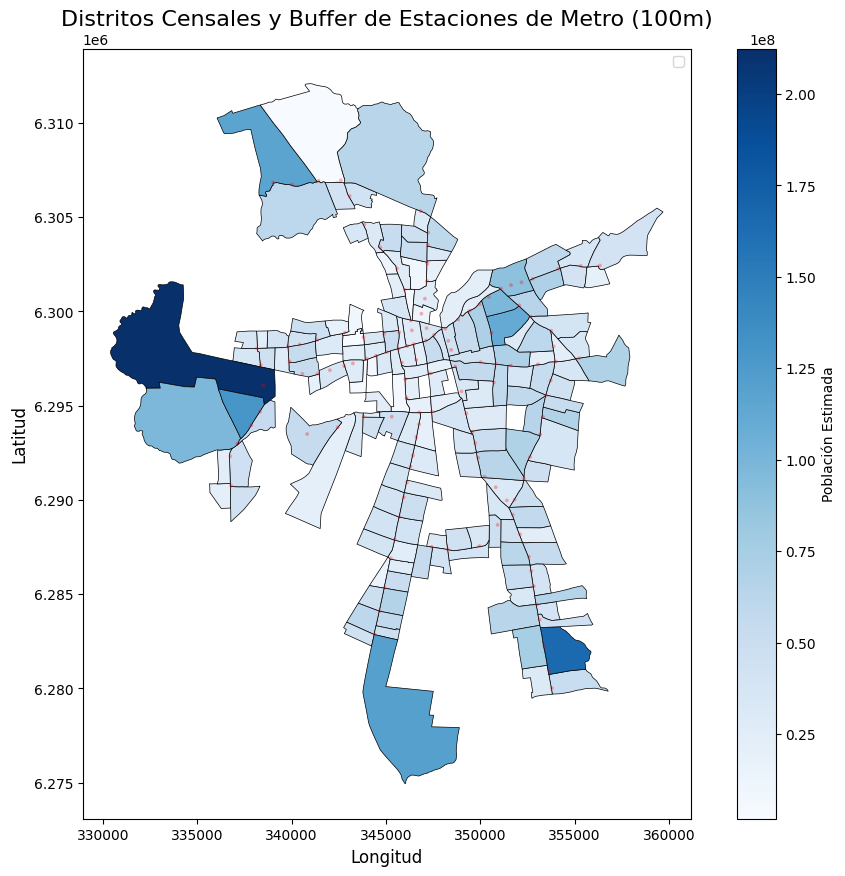

In [41]:
# Graficamos los distritos censales con un esquema de colores basado en la población
fig, ax = plt.subplots(figsize=(12, 10))

# Graficamos los distritos con el color basado en la población y bordes negros
distritos_metro.plot(
    ax=ax, 
    column='Poblacion', 
    cmap='Blues',  # Usamos una paleta de colores más distintiva
    edgecolor='black', 
    linewidth=0.5, 
    legend=True, 
    legend_kwds={'label': "Población Estimada", 'orientation': "vertical"}
)

# Superponemos el buffer de las estaciones de metro, en un color rojo semi-transparente
buffer_estaciones_metro.plot(
    ax=ax, 
    alpha=0.3,  # Hacemos el buffer semi-transparente para que no oculte los distritos
    color='red', 
    label='Buffer de Estaciones de Metro'
)

# Añadimos un título y etiquetas
plt.title('Distritos Censales y Buffer de Estaciones de Metro (100m)', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Añadimos una leyenda para los buffers
plt.legend(loc='upper right')

# Mostramos el gráfico
plt.show()

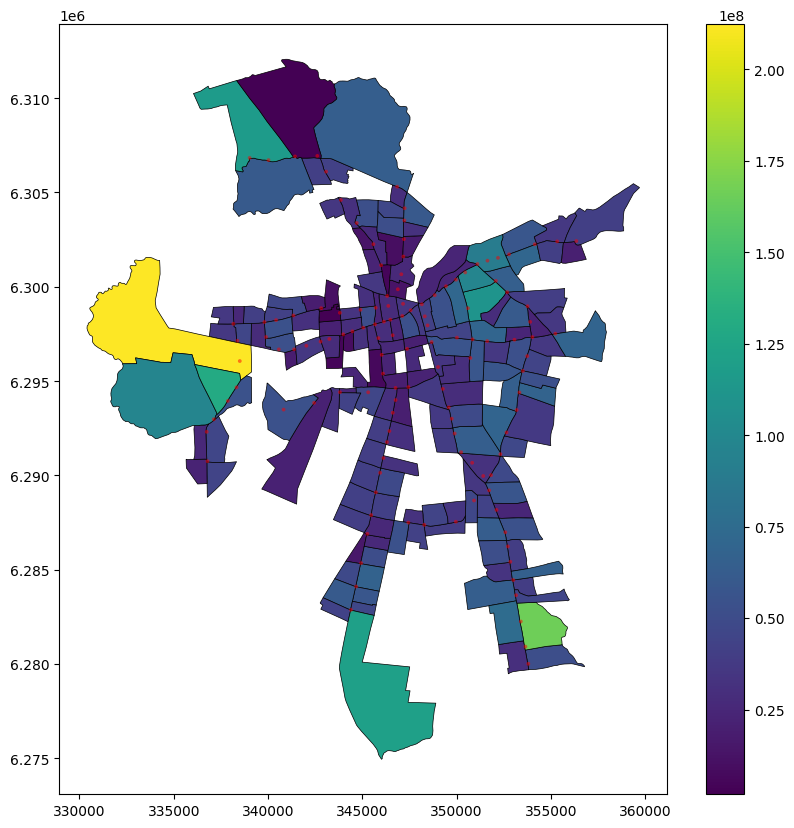

In [42]:
ax = distritos_metro.plot(figsize = (10,10), column = 'Poblacion', edgecolor = 'black', linewidth = 0.5,legend = True)
ax1 = buffer_estaciones_metro.plot(ax=ax, alpha = 0.5, color = 'red')

En esta visualización final, hemos representado los distritos censales cercanos a las estaciones de metro, coloreados según su población estimada. Utilizamos una escala de colores basada en el número de habitantes, lo que permite identificar de manera intuitiva los distritos más densamente poblados dentro del área de influencia de las estaciones de metro.

Además, hemos añadido los buffers de 100 metros alrededor de las estaciones de metro, representados en color rojo semi-transparente. Esto nos permite visualizar claramente las áreas de influencia de las estaciones de metro sin perder de vista los distritos y su respectiva población.

Este análisis nos proporciona una visión clara de los distritos más poblados con acceso cercano al transporte público. Esta información es útil para la planificación urbana y el desarrollo de infraestructura, ya que permite identificar las áreas donde una mayor cantidad de personas tiene acceso directo al sistema de metro. En conjunto, este gráfico concluye el análisis espacial, integrando de manera efectiva la población y el transporte.


# Material Complementario 
# Misión 1 E2: Visualización de distritos censales con métrica de diversidad socioeconómica

En esta misión, nos enfocaremos en graficar los distritos censales de la Región Metropolitana que pertenecen a la provincia con más distritos. Para hacer la visualización más informativa, aplicaremos una escala de colores basada en una métrica de diversidad socioeconómica que será propuesta y calculada en función de los datos disponibles.

El objetivo de esta misión es identificar los distritos de la provincia más poblada y, al mismo tiempo, analizar las diferencias socioeconómicas entre ellos. Este análisis nos permitirá visualizar cómo se distribuyen los diferentes niveles socioeconómicos dentro de la provincia con más distritos, proporcionando información valiosa para la planificación urbana y el desarrollo de políticas públicas.

A continuación, comenzaremos el proceso de selección y visualización de los distritos censales, así como el cálculo de la métrica de diversidad socioeconómica.


In [43]:
import geopandas as gpd
import pandas as pd
from IPython.display import display #para mostrar más de un elemento por celda de Jupyter

Se realizará los mismos procesos que para E1, por ende no se explicarán tan en detalle cuando sean *similares*.

In [44]:
distritos = gpd.read_file('Data/Distritos Censales/Distritos Censales RM.shp')
distritos.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.840, 345650.511 6..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.320 6298892.632, 345672.277 6..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."


In [45]:
distritos['NOM_PROV'].value_counts()

NOM_PROV
Santiago      312
Melipilla      41
Maipo          34
Cordillera     26
Talagante      20
Chacabuco      16
Name: count, dtype: int64

In [46]:
distritos_santiago = distritos.loc[distritos['NOM_PROV']=='Santiago']

In [47]:
chile_urbano = gpd.read_file('Data/Areas Urbanas/areas_urbanas.shp')
santiago_urbano = chile_urbano.loc[chile_urbano['NOMBRE']=='Santiago']

Revisar proyecciones:

In [48]:
distritos_santiago.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [49]:
santiago_urbano.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

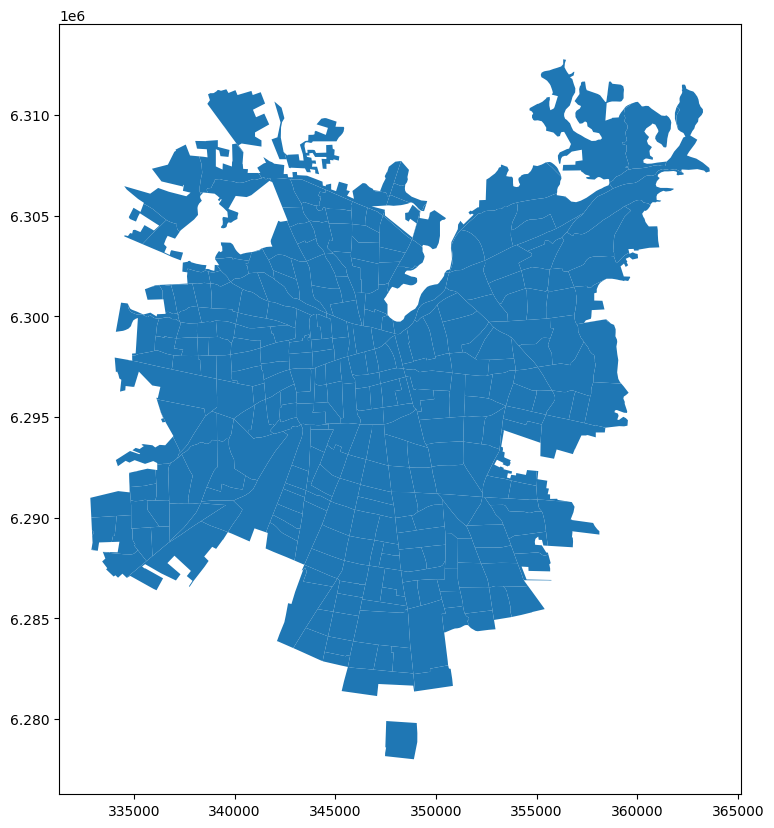

In [50]:
distritos_santiago_urbano = gpd.overlay(santiago_urbano, distritos_santiago, how='intersection')
distritos_santiago_urbano.plot(figsize=(10,10))

In [51]:
distritos_santiago_urbano.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6..."
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.610 6299612.269, 346298.704 6..."
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.570, 345809.442 6..."
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6..."
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6..."


En este código, estamos añadiendo una nueva columna llamada `Nivel_Diversidad_de_Nivel_Socioeconomico` al GeoDataFrame `distritos_santiago_urbano`, utilizando el **Índice de Herfindahl-Hirschman (HH)** como métrica para medir la diversidad socioeconómica de cada distrito. Este índice es comúnmente utilizado para evaluar la concentración o diversidad de un mercado o, en este caso, de los niveles socioeconómicos en una región.

El cálculo del índice HH se realiza sumando los cuadrados de las proporciones de cada grupo socioeconómico en el total de la población del distrito. Un valor más bajo del índice indica mayor diversidad, ya que significa que los grupos socioeconómicos están distribuidos de manera más equitativa. Por el contrario, un valor más alto indica una mayor concentración de un grupo específico, lo que implica menor diversidad.

Aquí están los detalles de la fórmula aplicada:
- **E, D, C3, C2, ABC1**: Son las categorías de niveles socioeconómicos del distrito. Cada uno representa un segmento socioeconómico distinto.
- **ADIMARK_T**: Es el total de hogares en el distrito.
- Para cada nivel socioeconómico, dividimos el número de hogares en esa categoría por el total de hogares (`ADIMARK_T`) para obtener la proporción.
- Luego, elevamos al cuadrado estas proporciones y sumamos los resultados para obtener el valor final del índice HH.

La fórmula completa para calcular el Índice de Herfindahl-Hirschman (HH) es:

HH = (E / T)^2 + (D / T)^2 + (C3 / T)^2 + (C2 / T)^2 + (ABC1 / T)^2

Donde:
- **E**: Número de hogares de clase E.
- **D**: Número de hogares de clase D.
- **C3**: Número de hogares de clase C3.
- **C2**: Número de hogares de clase C2.
- **ABC1**: Número de hogares de clase ABC1.
- **T**: Es el total de hogares en el distrito (ADIMARK_T).

Este índice se calcula sumando los cuadrados de las proporciones de cada grupo socioeconómico dentro del total de hogares del distrito. Cuanto menor sea el valor de HH, mayor será la diversidad socioeconómica.


Este cálculo nos permitirá visualizar y comparar la diversidad socioeconómica entre los distritos censales, proporcionando una métrica valiosa para el análisis urbano.


In [52]:
distritos_santiago_urbano["Nivel_Diversidad_de_Nivel_Socioeconomico"] = (distritos_santiago_urbano["E"]/distritos_santiago_urbano["ADIMARK_T"])**2 + (distritos_santiago_urbano["D"]/distritos_santiago_urbano["ADIMARK_T"])**2 + (distritos_santiago_urbano["C3"]/distritos_santiago_urbano["ADIMARK_T"])**2 + (distritos_santiago_urbano["C2"]/distritos_santiago_urbano["ADIMARK_T"])**2 + (distritos_santiago_urbano["ABC1"]/distritos_santiago_urbano["ADIMARK_T"])**2

In [53]:
distritos_santiago_urbano.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,Nivel_Diversidad_de_Nivel_Socioeconomico
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6...",0.321390
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.610 6299612.269, 346298.704 6...",0.290373
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.570, 345809.442 6...",0.328787
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6...",0.329696
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6...",0.306708


<Axes: >

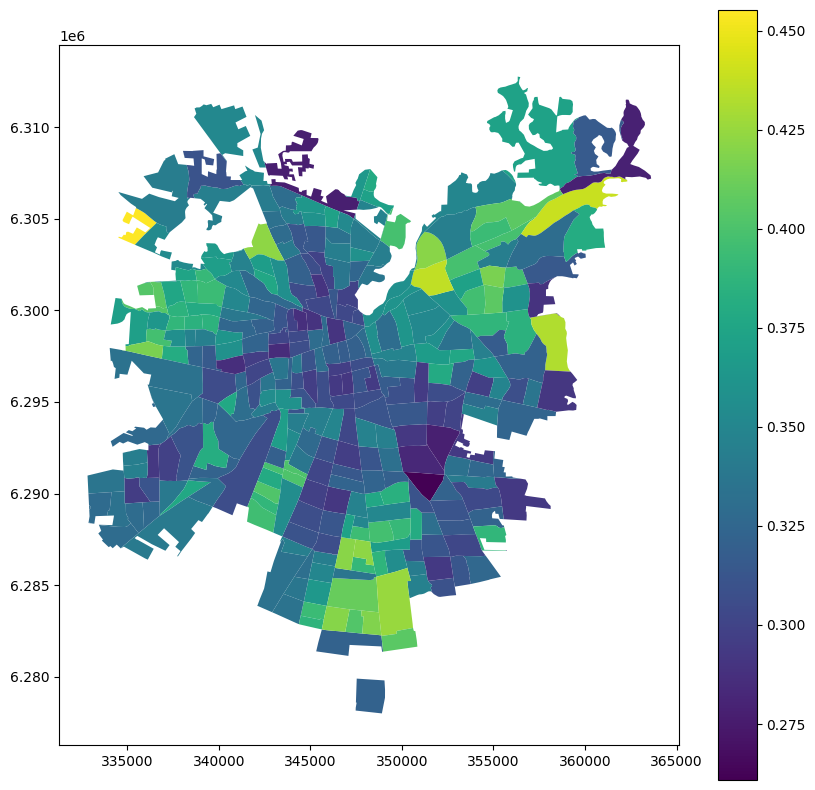

In [55]:
distritos_santiago_urbano.plot(column='Nivel_Diversidad_de_Nivel_Socioeconomico', figsize = (10,10), legend=True)

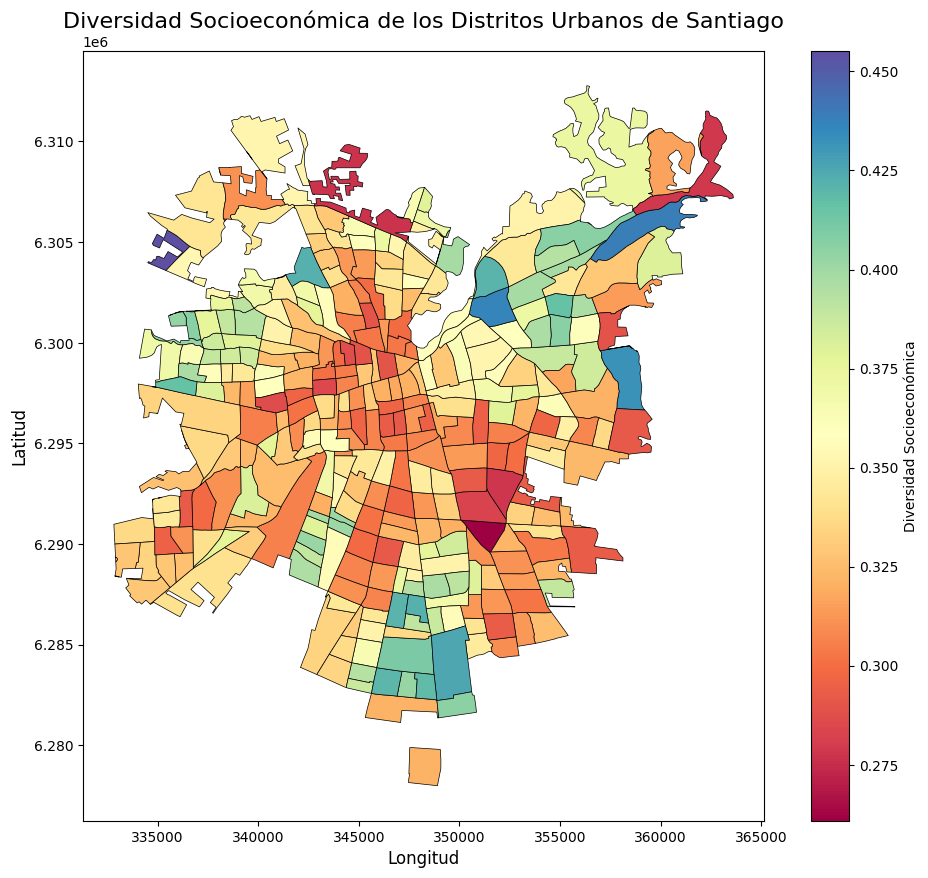

In [54]:
# Graficamos los distritos de Santiago urbano con una escala de colores basada en la diversidad socioeconómica
fig, ax = plt.subplots(figsize=(12, 10))

# Usamos la métrica 'Nivel_Diversidad_de_Nivel_Socioeconomico' para colorear los distritos
distritos_santiago_urbano.plot(
    column='Nivel_Diversidad_de_Nivel_Socioeconomico',
    ax=ax,
    cmap='Spectral',  # Usamos una paleta de colores atractiva
    edgecolor='black',  # Añadimos bordes negros para delimitar los distritos
    linewidth=0.5,  # Ajustamos el grosor de los bordes
    legend=True,
    legend_kwds={'label': "Diversidad Socioeconómica", 'orientation': "vertical"}  # Personalizamos la leyenda
)

# Añadimos un título y etiquetas a los ejes
plt.title('Diversidad Socioeconómica de los Distritos Urbanos de Santiago', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, hemos representado los distritos urbanos de Santiago utilizando la métrica `Nivel_Diversidad_de_Nivel_Socioeconomico`, que mide la diversidad de los niveles socioeconómicos en cada distrito. 

Para hacer el gráfico más interesante, hemos aplicado las siguientes mejoras:
- **Paleta de colores (`cmap='Spectral'`)**: Utilizamos la paleta de colores `Spectral`, que proporciona un gradiente de colores atractivos y fácilmente diferenciables. Esto facilita la identificación de distritos con mayor o menor diversidad.
- **Bordes y grosor**: Los bordes negros y un grosor ajustado hacen que las divisiones entre distritos sean más claras y definidas, mejorando la legibilidad del mapa.
- **Leyenda personalizada**: Añadimos una leyenda clara que describe el significado de los colores, indicando que representan el nivel de diversidad socioeconómica, con una orientación vertical para facilitar la lectura.

El gráfico nos proporciona una representación visual clara de cómo varía la diversidad socioeconómica entre los distritos de Santiago, permitiendo una rápida identificación de las zonas con mayor o menor concentración de grupos socioeconómicos.


## Misión 2: Identificación de estaciones de metro con tres o más distritos censales a menos de 100 metros

En esta misión, nuestro objetivo es identificar las estaciones de metro que tienen tres o más distritos censales a menos de 100 metros de distancia. Para lograrlo, realizaremos un análisis espacial utilizando los datos de las estaciones de metro y los distritos censales.

Primero, crearemos un **buffer** de 100 metros alrededor de cada estación de metro para definir su área de influencia. Luego, utilizaremos una unión espacial (`spatial join`) para determinar cuáles distritos intersectan con los buffers de las estaciones. Finalmente, contaremos cuántos distritos intersectan con cada estación de metro y seleccionaremos aquellas que están asociadas a tres o más distritos.

Este análisis es importante porque nos permitirá identificar las áreas donde el acceso al transporte público es más diverso, lo que puede ser útil para estudios de planificación urbana y optimización de la infraestructura de transporte.


In [56]:
estaciones_metro = gpd.read_file('Data/Metro 2020/Estaciones_2020/Estaciones_2020.shp')
estaciones_metro.head()

,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,POINT (345717.366 6289105.444)
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,POINT (344899.120 6298781.571)
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,POINT (343808.803 6298622.125)
3,5,7,L4A,SAN RAMON,San Ramón,346685.4133,6.287624e+06,POINT (347436.975 6287501.270)
4,6,7,L4A,SANTA ROSA,Santa Rosa,348282.5816,6.287378e+06,POINT (348282.582 6287378.409)


In [57]:
estaciones_metro.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [58]:
# Generamos el buffer de las estaciones de metro
buffer_estaciones_metro = estaciones_metro.copy()
buffer_estaciones_metro.geometry = buffer_estaciones_metro.buffer(100)

In [59]:
distritos_metro = gpd.sjoin(distritos, buffer_estaciones_metro, predicate='intersects')

In [60]:
# Se agrupan por estación
agrupando_distritos_estaciones = distritos_metro.groupby("ESTACION")
display(agrupando_distritos_estaciones.head(10))

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,1_UF_M2,geometry,index_right,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06
9,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,1310110.0,28.0,394.0,1225.0,...,18.44,"POLYGON ((347488.430 6298672.836, 347569.109 6...",62,65,1,L1,UNIVERSIDAD CATOLICA,Universidad Católica,347551.3269,6.298747e+06
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",60,63,1,L1,SANTA LUCIA,Santa Lucía,347075.4514,6.298439e+06
10,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Isidro,1310111.0,53.0,779.0,1892.0,...,14.81,"POLYGON ((346958.269 6298373.448, 347071.088 6...",60,63,1,L1,SANTA LUCIA,Santa Lucía,347075.4514,6.298439e+06
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",80,84,5,L5,BELLAS ARTES,Bellas Artes,347155.8810,6.299103e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,Región Metropolitana De Santiago,132,Cordillera,13201,Puente Alto,Teniente Bello,1320115.0,133.0,848.0,1054.0,...,3.35,"POLYGON ((352221.696 6281031.729, 352739.578 6...",7,9,4,L4,LAS MERCEDES,Las Mercedes,353659.7532,6.280834e+06
319,Región Metropolitana De Santiago,132,Cordillera,13201,Puente Alto,San Carlos,1320108.0,92.0,3321.0,7148.0,...,2.49,"POLYGON ((353187.333 6283228.924, 354229.424 6...",82,86,4,L4,PROTECTORA DE LA INFANCIA,Protectora de la Infancia,353400.3951,6.282256e+06
328,Región Metropolitana De Santiago,132,Cordillera,13201,Puente Alto,Padre Hurtado,1320117.0,182.0,2200.0,3323.0,...,5.83,"POLYGON ((353164.445 6283352.105, 353187.333 6...",82,86,4,L4,PROTECTORA DE LA INFANCIA,Protectora de la Infancia,353400.3951,6.282256e+06
320,Región Metropolitana De Santiago,132,Cordillera,13201,Puente Alto,Sótero del Río,1320109.0,31.0,763.0,1730.0,...,2.78,"POLYGON ((354239.318 6283649.540, 354751.933 6...",9,11,4,L4,SOTERO DEL RIO,Sotero del Río,353150.0575,6.283649e+06


En esta línea de código, agrupamos los distritos censales cercanos a las estaciones de metro por cada estación.

- **`distritos_metro.groupby("ESTACION")`**: Agrupa los datos del GeoDataFrame `distritos_metro` en función de la columna `ESTACION`, que contiene el nombre o identificador de cada estación de metro. Esto nos permite agrupar todos los distritos censales que están dentro del área de influencia de una estación (en este caso, a menos de 100 metros).
  
- **`display(agrupando_distritos_estaciones.head(10))`**: Muestra los primeros 10 registros de los distritos agrupados por estación de metro. Esto nos permite visualizar cómo se ha realizado la agrupación, y verificar que los distritos censales han sido correctamente asignados a las estaciones de metro más cercanas.

Agrupar los distritos por estación es un paso importante para identificar cuántos distritos están asociados a cada estación, lo que será clave para la siguiente etapa del análisis, donde seleccionaremos aquellas estaciones con tres o más distritos en su área de influencia.


In [61]:
# Se filtran para obtener las estaciones que tienen 3 o más distritos a 100 metros
estaciones_filtradas = agrupando_distritos_estaciones.filter(lambda grupo: len(grupo) >= 3)
display(estaciones_filtradas.head(10))

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,1_UF_M2,geometry,index_right,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,...,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6...",55,58,1,L1,LA MONEDA,La Moneda,346187.8506,6.298170e+06
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,...,12.00,"POLYGON ((345546.017 6299748.840, 345650.511 6...",55,58,1,L1,LA MONEDA,La Moneda,346187.8506,6.298170e+06
12,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Almagro,1310113.0,33.0,404.0,1037.0,...,14.31,"POLYGON ((346079.016 6298132.104, 346463.160 6...",55,58,1,L1,LA MONEDA,La Moneda,346187.8506,6.298170e+06
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,...,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6...",59,62,1,COMB,UNIVERSIDAD DE CHILE,Universidad de Chile,346604.8868,6.298297e+06
11,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Universidad,1310112.0,35.0,429.0,880.0,...,14.05,"POLYGON ((346463.160 6298239.524, 346522.174 6...",59,62,1,COMB,UNIVERSIDAD DE CHILE,Universidad de Chile,346604.8868,6.298297e+06
12,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Almagro,1310113.0,33.0,404.0,1037.0,...,14.31,"POLYGON ((346079.016 6298132.104, 346463.160 6...",59,62,1,COMB,UNIVERSIDAD DE CHILE,Universidad de Chile,346604.8868,6.298297e+06
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,...,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6...",61,64,2,COMB,CAL Y CANTO,Cal y Canto,346403.1922,6.299489e+06
82,Región Metropolitana De Santiago,131,Santiago,13108,Independencia,Independencia,1310801.0,76.0,978.0,1423.0,...,8.72,"POLYGON ((346040.296 6300810.440, 346090.704 6...",61,64,2,COMB,CAL Y CANTO,Cal y Canto,346403.1922,6.299489e+06
88,Región Metropolitana De Santiago,131,Santiago,13108,Independencia,Escuela de Medicina,1310807.0,6.0,91.0,212.0,...,7.54,"POLYGON ((346309.028 6301169.632, 346329.781 6...",61,64,2,COMB,CAL Y CANTO,Cal y Canto,346403.1922,6.299489e+06
263,Región Metropolitana De Santiago,131,Santiago,13127,Recoleta,Recoleta,1312701.0,72.0,452.0,454.0,...,9.36,"POLYGON ((346452.427 6300342.572, 346556.912 6...",61,64,2,COMB,CAL Y CANTO,Cal y Canto,346403.1922,6.299489e+06


En esta línea de código, filtramos las estaciones de metro para quedarnos solo con aquellas que tienen tres o más distritos censales dentro de su área de influencia de 100 metros.

- **`agrupando_distritos_estaciones.filter(lambda grupo: len(grupo) >= 3)`**: Aplicamos una función de filtro (`filter`) sobre los grupos creados en el paso anterior. La función lambda `lambda grupo: len(grupo) >= 3` filtra los grupos de distritos asociados a una estación y solo selecciona aquellos que tienen tres o más distritos asociados. Es decir, mantenemos únicamente las estaciones de metro que tienen al menos tres distritos censales a menos de 100 metros.
  
- **`display(estaciones_filtradas.head(10))`**: Muestra las primeras 10 filas del GeoDataFrame `estaciones_filtradas`, que contiene solo las estaciones de metro que cumplen con el criterio de tener tres o más distritos cercanos.

Este paso es clave para identificar las estaciones de metro con mayor diversidad en términos de accesibilidad a distritos censales, lo cual puede ser relevante para la planificación y optimización del transporte público en esas áreas.


In [62]:
# Para encontrar los distintos valores podemos usar el método value_counts en la columna "ESTACION"
estaciones_filtradas["ESTACION"].value_counts()

ESTACION
GRECIA                   5
PLAZA EGANA              4
ÑUÑOA                    4
SAN PABLO                4
PUDAHUEL                 4
FRANCISCO BILBAO         4
SANTA ROSA               4
ELISA CORREA             4
EL PARRON                4
LA CISTERNA              4
HOSPITAL EL PINO         4
OBSERVATORIO             4
LO MARTÏNEZ              4
ESTACION CENTRAL         4
LOS HEROES               4
CAL Y CANTO              4
BLANQUEADO               4
BIO BIO                  4
PLAZA DE MAIPU           3
EFE QUILICURA            3
CEMENTERIOS              3
EINSTEIN                 3
LOS PRESIDENTES          3
DEL SOL                  3
ZAPADORES                3
CARLOS VALDOVINOS        3
QUILIIN                  3
DORSAL                   3
MACUL                    3
BARRANCAS                3
ESTADIO NACIONAL         3
LA MONEDA                3
NEPTUNO                  3
LO VALLEDOR              3
SANTA ANA                3
REPUBLICA                3
UNION LATINOAMERICA

En esta línea de código, utilizamos el método `value_counts()` para contar cuántas veces aparece cada estación de metro en la columna "ESTACION" del DataFrame filtrado.

- **`estaciones_filtradas["ESTACION"].value_counts()`**: Este método cuenta cuántas veces cada valor único aparece en la columna `ESTACION`, es decir, cuántos distritos censales están asociados a cada estación. Después de aplicar el filtro para quedarnos con las estaciones que tienen tres o más distritos a menos de 100 metros, esta función nos permite ver cuántos distritos tiene cada estación en su área de influencia.

El resultado de esta línea de código es una serie en la que se muestran las estaciones de metro y el número de distritos censales cercanos a cada una. Este conteo nos ayuda a identificar fácilmente las estaciones con el mayor número de distritos censales dentro de su área de influencia, lo que es útil para priorizar áreas con mayor accesibilidad al transporte público.


## Misión 3: Ranking de comunas con más estaciones de metro

En esta misión, nuestro objetivo es realizar un ranking de las comunas de la Región Metropolitana que cuentan con más estaciones de metro. Para ello, utilizaremos los datos geoespaciales de las estaciones de metro y las comunas, y determinaremos cuántas estaciones están ubicadas dentro de los límites de cada comuna.

El procedimiento incluirá la creación de una unión espacial entre las estaciones de metro y las comunas para identificar qué estaciones pertenecen a cada comuna. Luego, contaremos el número de estaciones por comuna y generaremos un ranking basado en este conteo. Finalmente, visualizaremos los resultados tanto en una tabla como en un mapa, lo que nos permitirá observar qué comunas tienen mejor acceso al sistema de transporte público.

Este análisis es importante para evaluar la accesibilidad al transporte en las distintas comunas, identificar posibles desequilibrios en la distribución de estaciones, y servir como base para futuras decisiones de planificación urbana y desarrollo de infraestructuras.


In [63]:
estaciones_contenidas_en_distritos = gpd.sjoin(estaciones_metro, distritos, how="inner", predicate="within")
estaciones_contenidas_en_distritos.head()

,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry,index_right,NOM_REG,...,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,POINT (345717.366 6289105.444),91,Región Metropolitana De Santiago,...,1310903.0,68.0,1015.0,1768.0,1589.0,403.0,4843.0,1665542.63,29.08,4.97
40,43,2,L2,LO OVALLE,Lo Ovalle,345942.8141,6.290139e+06,POINT (345942.814 6290138.514),91,Región Metropolitana De Santiago,...,1310903.0,68.0,1015.0,1768.0,1589.0,403.0,4843.0,1665542.63,29.08,4.97
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,POINT (344899.120 6298781.571),3,Región Metropolitana De Santiago,...,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25
49,52,1,L1,REPUBLICA,República,345054.7146,6.297837e+06,POINT (345045.848 6297833.614),3,Región Metropolitana De Santiago,...,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,POINT (343808.803 6298622.125),28,Región Metropolitana De Santiago,...,1310129.0,13.0,58.0,81.0,41.0,5.0,198.0,732908.67,2.70,5.61


En esta línea de código, utilizamos la función `gpd.sjoin()` para realizar una unión espacial (*spatial join*) entre los datos de las estaciones de metro y los distritos censales, con el objetivo de encontrar qué estaciones de metro están contenidas dentro de los distritos.

- **`gpd.sjoin(estaciones_metro, distritos, how="inner", predicate="within")`**: Esta función realiza una unión espacial entre las estaciones de metro y los distritos. El parámetro `how="inner"` indica que queremos una unión interna, lo que significa que se seleccionarán solo las estaciones que tienen una intersección espacial con los distritos. El parámetro `predicate="within"` especifica que estamos buscando las estaciones de metro que están completamente contenidas (*within*) dentro de los distritos censales.
  
- **`estaciones_contenidas_en_distritos.head()`**: Muestra las primeras filas del GeoDataFrame resultante `estaciones_contenidas_en_distritos`, el cual contiene las estaciones de metro que están dentro de algún distrito censal.

Este paso es fundamental para identificar qué estaciones de metro se encuentran dentro de los límites de los distritos censales, lo que luego nos permitirá asociar cada estación a una comuna específica en el siguiente paso del análisis.


In [64]:
df_comunas_estaciones = estaciones_contenidas_en_distritos.groupby("NOM_COM", as_index=False).size()
display(df_comunas_estaciones.head(10))

,NOM_COM,size
0,Cerrillos,2
1,Conchalí,3
2,El Bosque,3
3,Estación Central,3
4,Huechuraba,1
5,Independencia,2
6,La Cisterna,4
7,La Florida,9
8,La Granja,2
9,La Reina,5


En esta línea de código, agrupamos las estaciones de metro que están contenidas dentro de los distritos censales en función de las comunas a las que pertenecen, y luego contamos cuántas estaciones tiene cada comuna.

- **`estaciones_contenidas_en_distritos.groupby("NOM_COM", as_index=False).size()`**: Utilizamos el método `groupby()` para agrupar las estaciones de metro por la columna `NOM_COM`, que representa el nombre de la comuna. Luego, utilizamos el método `size()` para contar cuántas estaciones tiene cada comuna. El parámetro `as_index=False` asegura que el resultado sea un DataFrame y que `NOM_COM` se mantenga como una columna y no como un índice.
  
- **`display(df_comunas_estaciones.head(10))`**: Muestra las primeras 10 filas del DataFrame `df_comunas_estaciones`, que contiene el número de estaciones de metro en cada comuna. Esto nos permite ver rápidamente las comunas con más (o menos) estaciones de metro.

Este paso es crucial para generar el ranking de las comunas con más estaciones de metro, lo que nos ayudará a visualizar las diferencias en la accesibilidad al transporte público entre las distintas comunas.


In [65]:
df_comunas_estaciones.columns = ["NOM_COM", "N_ESTACIONES"]
display(df_comunas_estaciones.head(10))

,NOM_COM,N_ESTACIONES
0,Cerrillos,2
1,Conchalí,3
2,El Bosque,3
3,Estación Central,3
4,Huechuraba,1
5,Independencia,2
6,La Cisterna,4
7,La Florida,9
8,La Granja,2
9,La Reina,5


En esta línea de código, renombramos las columnas del DataFrame `df_comunas_estaciones` para hacerlas más descriptivas y facilitar la comprensión del contenido.

- **`df_comunas_estaciones.columns = ["NOM_COM", "N_ESTACIONES"]`**: Cambiamos el nombre de las columnas del DataFrame para que sean más claras. La primera columna, que anteriormente contenía el nombre de la comuna, ahora se llama `NOM_COM`, y la segunda columna, que contiene el número de estaciones de metro en cada comuna, ha sido renombrada como `N_ESTACIONES`.
  
  - **`NOM_COM`**: Representa el nombre de la comuna.
  - **`N_ESTACIONES`**: Representa el número de estaciones de metro que tiene cada comuna.
  
- **`display(df_comunas_estaciones.head(10))`**: Muestra las primeras 10 filas del DataFrame para que podamos verificar que las columnas han sido renombradas correctamente y que el contenido es claro.

Este paso mejora la legibilidad del DataFrame al utilizar nombres de columnas más intuitivos, lo que facilita el análisis y la interpretación de los datos en los siguientes pasos del ranking.


In [66]:
df_comunas_estaciones_ranking = df_comunas_estaciones.sort_values(by=["N_ESTACIONES"], ascending=False)
df_comunas_estaciones_ranking.head()

,NOM_COM,N_ESTACIONES
24,Santiago,22
7,La Florida,9
16,Providencia,8
10,Las Condes,8
25,Ñuñoa,7


En esta línea de código, ordenamos las comunas por el número de estaciones de metro en orden descendente para generar un ranking.

- **`df_comunas_estaciones.sort_values(by=["N_ESTACIONES"], ascending=False)`**: Ordenamos el DataFrame `df_comunas_estaciones` por la columna `N_ESTACIONES`, que contiene el número de estaciones de metro en cada comuna. El parámetro `ascending=False` asegura que el orden sea descendente, es decir, las comunas con más estaciones aparecerán primero, generando así el ranking.
  
- **`df_comunas_estaciones_ranking.head()`**: Muestra las primeras filas del DataFrame ordenado, `df_comunas_estaciones_ranking`, que ahora contiene las comunas en orden descendente según el número de estaciones de metro que tienen.

Este paso es esencial para generar un ranking de las comunas con más estaciones de metro, lo que nos permitirá identificar rápidamente qué comunas tienen mejor acceso al sistema de transporte público.


In [68]:
distritos_copia = distritos.copy()
distritos_con_numero_estaciones = distritos_copia.merge(df_comunas_estaciones)
distritos_con_numero_estaciones.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,N_ESTACIONES
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6...",22
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.280 6299633.958, 345961.610 6...",22
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.840, 345650.511 6...",22
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.320 6298892.632, 345672.277 6...",22
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6...",22


En esta línea de código, realizamos una copia del GeoDataFrame de distritos y luego lo unimos con el DataFrame de comunas que contiene el número de estaciones de metro por comuna. Esto nos permitirá visualizar cuántas estaciones de metro están asociadas a cada distrito.

- **`distritos.copy()`**: Hacemos una copia del GeoDataFrame `distritos` y la almacenamos en `distritos_copia`. Esto es útil para preservar el conjunto de datos original en caso de que se necesiten realizar otras manipulaciones en los distritos más adelante.
  
- **`distritos_copia.merge(df_comunas_estaciones)`**: Realizamos una unión de datos (*merge*) entre `distritos_copia` y el DataFrame `df_comunas_estaciones`, que contiene el número de estaciones de metro por comuna. Esta unión se hace automáticamente en función de la columna común entre ambos DataFrames, que es `NOM_COM` (el nombre de la comuna). Como resultado, cada distrito en `distritos_copia` ahora tendrá asociado el número de estaciones de metro en la comuna a la que pertenece.
  
- **`distritos_con_numero_estaciones.head()`**: Muestra las primeras filas del GeoDataFrame resultante `distritos_con_numero_estaciones`, que contiene los distritos censales junto con el número de estaciones de metro en su respectiva comuna.

Este paso nos permite añadir una nueva capa de información a los distritos censales, asociando el número de estaciones de metro en su comuna, lo que será útil para posteriores análisis y visualizaciones.


<Axes: >

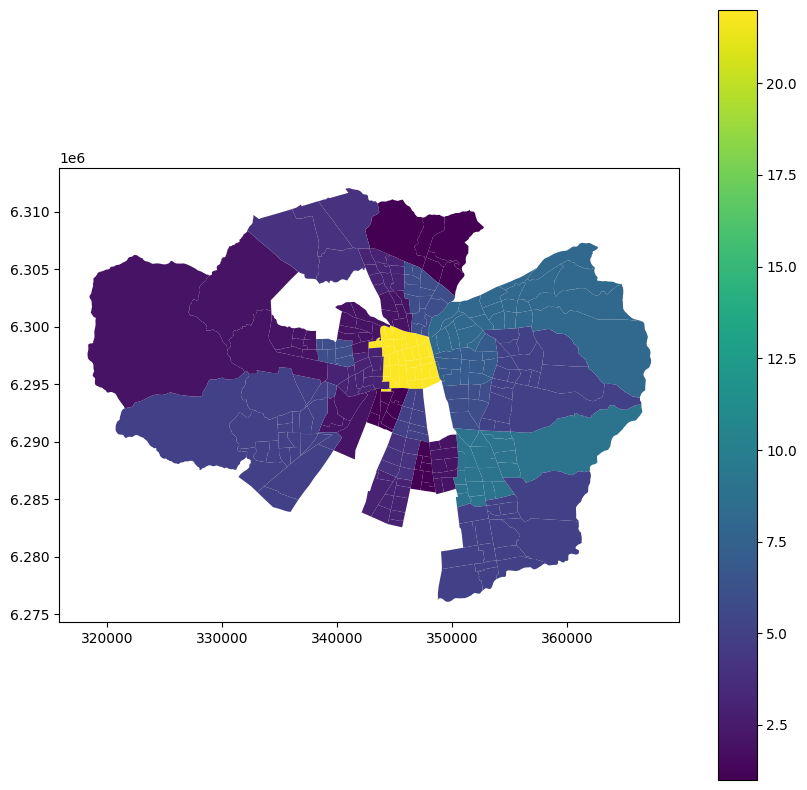

In [70]:
distritos_con_numero_estaciones.plot(column='N_ESTACIONES', figsize = (10,10), legend=True)

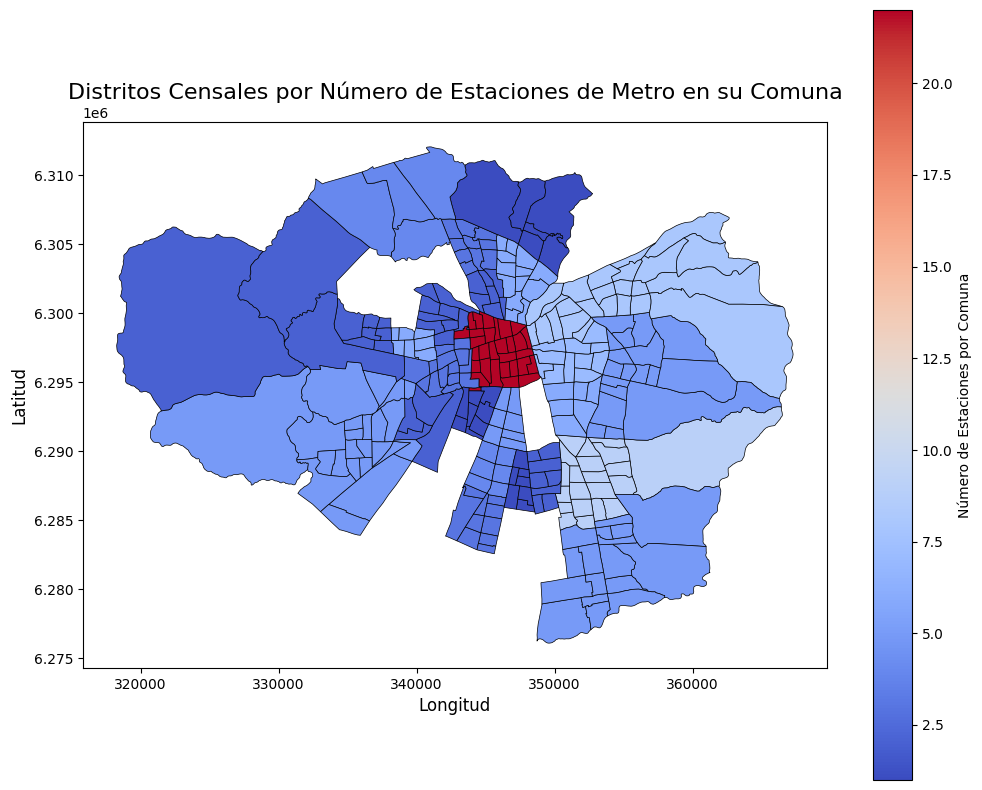

In [69]:
# Graficamos los distritos coloreados por el número de estaciones en la comuna
fig, ax = plt.subplots(figsize=(12, 10))

# Graficamos los distritos con un esquema de colores basado en el número de estaciones
distritos_con_numero_estaciones.plot(
    column='N_ESTACIONES',
    ax=ax,
    cmap='coolwarm',  # Usamos una paleta de colores atractiva y fácil de interpretar
    edgecolor='black',  # Bordes negros para los distritos
    linewidth=0.5,  # Grosor del borde
    legend=True,
    legend_kwds={'label': "Número de Estaciones por Comuna", 'orientation': "vertical"}  # Personalización de la leyenda
)

# Añadimos un título y etiquetas en los ejes
plt.title('Distritos Censales por Número de Estaciones de Metro en su Comuna', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()

En este gráfico, hemos representado los distritos censales de la Región Metropolitana utilizando una escala de colores que refleja el número de estaciones de metro en la comuna a la que pertenece cada distrito. Este enfoque nos permite visualizar de manera clara cómo se distribuyen las estaciones de metro a lo largo de las comunas.

Algunas mejoras incluidas en el gráfico son:
- **Paleta de colores (`cmap='coolwarm'`)**: Usamos una paleta de colores que proporciona un gradiente claro desde colores cálidos (para comunas con menos estaciones) hasta colores fríos (para comunas con más estaciones).
- **Bordes negros**: Los distritos tienen bordes negros para una mejor delimitación entre ellos, lo que mejora la legibilidad del mapa.
- **Leyenda personalizada**: Hemos añadido una leyenda clara que indica que los colores representan el número de estaciones por comuna, con orientación vertical para facilitar la lectura.
- **Título y etiquetas**: El gráfico incluye un título descriptivo y etiquetas en los ejes para proporcionar mayor contexto a la visualización.

Este gráfico proporciona una visión clara de cómo el número de estaciones de metro varía entre las comunas, lo que puede ser útil para identificar posibles desequilibrios en la infraestructura de transporte público.


<Axes: >

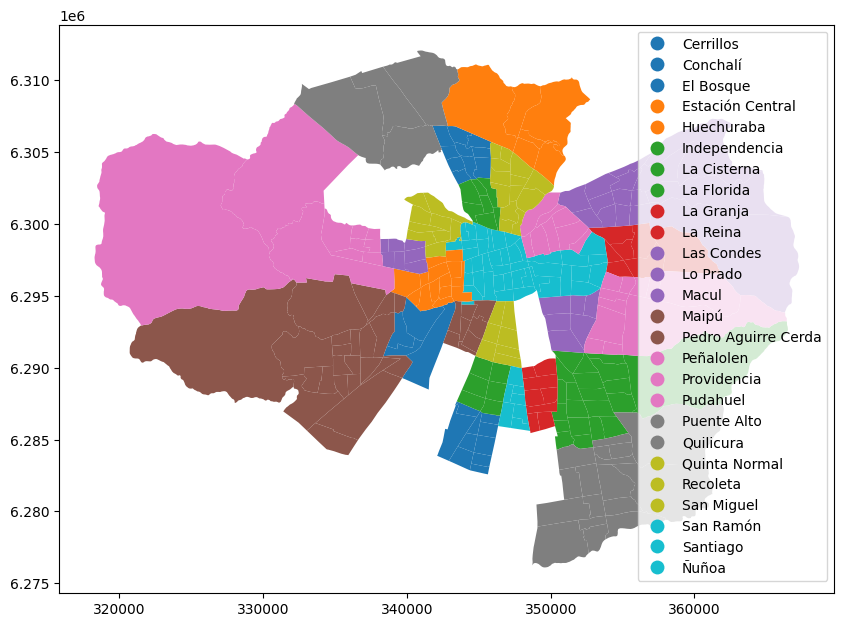

In [71]:
distritos_con_numero_estaciones.plot(column='NOM_COM', figsize = (10,10), legend=True)

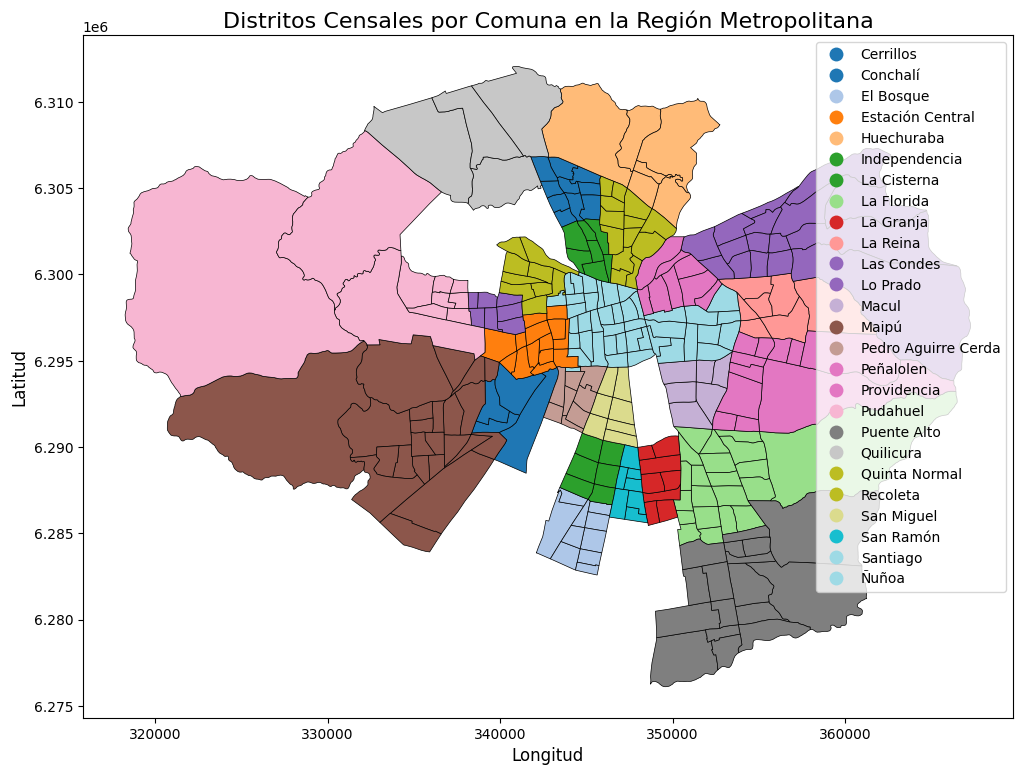

In [74]:
# Graficamos los distritos censales coloreados según el nombre de la comuna
fig, ax = plt.subplots(figsize=(12, 10))

# Graficamos los distritos con un esquema de colores basado en la comuna
distritos_con_numero_estaciones.plot(
    column='NOM_COM',
    ax=ax,
    cmap='tab20',  # Usamos una paleta de colores categóricos para las diferentes comunas
    edgecolor='black',  # Bordes negros para los distritos
    linewidth=0.5,  # Grosor del borde
    legend=True  # Permitimos que GeoPandas maneje la leyenda por defecto
)

# Añadimos un título y etiquetas en los ejes
plt.title('Distritos Censales por Comuna en la Región Metropolitana', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Mostramos el gráfico
plt.show()